**Initial setup for all of continental USA, not just Florida anymore.**
- 14 May 2026 -- 18 May
- The actual modelling will be done in a separate notebook, *CONUS_modelling.ipynb* , to keep this one focused on data compilation and cleaning.

In [10]:
# --- Cell 1: Load POUS and print basic checks ---

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# File path for the county x storm event dataset
pous_path = r"C:\Users\teaching\Downloads\outage-recovery-forecasting\data_raw\POUS.csv"

# Load POUS
pous = pd.read_csv(pous_path)

# Standardise FIPS as strings with leading zeros preserved
pous["CountyFIPS"] = pous["CountyFIPS"].astype(str).str.zfill(5)

# Parse event_start as datetime
pous["event_start"] = pd.to_datetime(pous["event_start"])

# Basic sanity checks
print("POUS shape:", pous.shape)
print("\nColumns:")
print(pous.columns.tolist())

print("\nDtypes:")
print(pous.dtypes)

print("\nHead:")
print(pous.head())

print("\nDate range:")
print("Start:", pous["event_start"].min())
print("End:  ", pous["event_start"].max())

print("\nUnique counties:", pous["CountyFIPS"].nunique())
print("Unique storms:   ", pous["storm"].nunique())
print("Unique events:   ", pous.groupby(["CountyFIPS", "storm"]).ngroups)

print("\nMissing values per column:")
print(pous.isna().sum())

POUS shape: (1040, 13)

Columns:
['event_start', 'CountyFIPS', 'county_pop', 'pre_outage_tracked_customers', 'days_since_data_start', 'duration_hours', 'n_periods', 'integral', 'pop_hours_supply_lost', 'storm', 'duration_days', 'year', 'month']

Dtypes:
event_start                     datetime64[us]
CountyFIPS                                 str
county_pop                               int64
pre_outage_tracked_customers           float64
days_since_data_start                  float64
duration_hours                           int64
n_periods                                int64
integral                               float64
pop_hours_supply_lost                  float64
storm                                      str
duration_days                          float64
year                                     int64
month                                    int64
dtype: object

Head:
          event_start CountyFIPS  county_pop  pre_outage_tracked_customers  \
0 2017-06-21 16:00:00      54001    

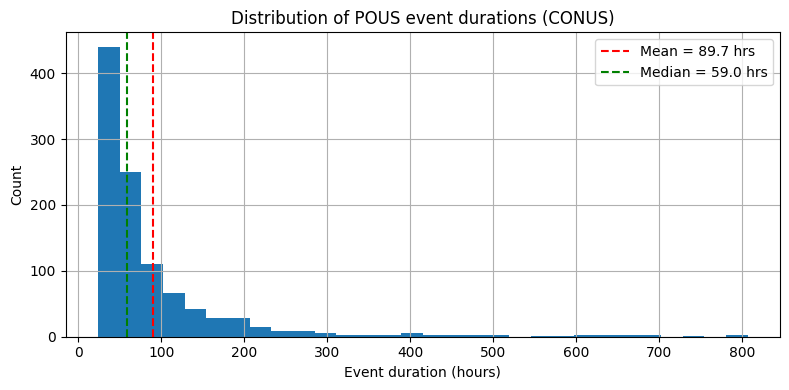

Duration summary:
count    1040.000000
mean       89.707692
std        99.504640
min        24.000000
25%        37.750000
50%        59.000000
75%        98.250000
max       807.000000
Name: duration_hours, dtype: float64

Mean duration:   89.71 hrs
Median duration: 59.00 hrs
Std dev:         99.50 hrs


In [11]:
# --- Cell 2: Histogram of event duration ---

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))

# Event duration distribution
pous["duration_hours"].hist(bins=30)

# Summary statistics for the plot
mean_val = pous["duration_hours"].mean()
median_val = pous["duration_hours"].median()
std_val = pous["duration_hours"].std()

# Reference lines
plt.axvline(mean_val, linestyle="--", color="red", label=f"Mean = {mean_val:.1f} hrs")
plt.axvline(median_val, linestyle="--", color="green", label=f"Median = {median_val:.1f} hrs")

plt.xlabel("Event duration (hours)")
plt.ylabel("Count")
plt.title("Distribution of POUS event durations (CONUS)")
plt.legend()
plt.tight_layout()
plt.show()

print("Duration summary:")
print(pous["duration_hours"].describe())
print(f"\nMean duration:   {mean_val:.2f} hrs")
print(f"Median duration: {median_val:.2f} hrs")
print(f"Std dev:         {std_val:.2f} hrs")

In [12]:
# --- Cell 3: Quick state-level event counts (useful CONUS sanity check) ---

# FIPS -> state code mapping
fips_to_state = {
    "01":"AL","02":"AK","04":"AZ","05":"AR","06":"CA","08":"CO","09":"CT","10":"DE",
    "11":"DC","12":"FL","13":"GA","15":"HI","16":"ID","17":"IL","18":"IN","19":"IA",
    "20":"KS","21":"KY","22":"LA","23":"ME","24":"MD","25":"MA","26":"MI","27":"MN",
    "28":"MS","29":"MO","30":"MT","31":"NE","32":"NV","33":"NH","34":"NJ","35":"NM",
    "36":"NY","37":"NC","38":"ND","39":"OH","40":"OK","41":"OR","42":"PA","44":"RI",
    "45":"SC","46":"SD","47":"TN","48":"TX","49":"UT","50":"VT","51":"VA","53":"WA",
    "54":"WV","55":"WI","56":"WY"
}

# Extract state FIPS from county code
pous["state_fips"] = pous["CountyFIPS"].str[:2]
pous["state"] = pous["state_fips"].map(fips_to_state)

state_counts = (
    pous.groupby(["state", "state_fips"])
    .size()
    .reset_index(name="n_events")
    .sort_values("n_events", ascending=False)
)

print("Top 10 states by number of POUS events:")
print(state_counts.head(10).to_string(index=False))

fl = state_counts.loc[state_counts["state"] == "FL", "n_events"]
if not fl.empty:
    print(f"\nFlorida event count: {int(fl.iloc[0])}")

Top 10 states by number of POUS events:
state state_fips  n_events
   GA         13       179
   LA         22       162
   NC         37       132
   FL         12        99
   VA         51        85
   MS         28        79
   AL         01        63
   TX         48        56
   SC         45        37
   AR         05        23

Florida event count: 99


In [ ]:
# --- Cell 4: Imports, paths, POUS load, parquet dataset setup ---

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Efficient parquet access for the very large CONUS time series file
import pyarrow.dataset as ds

# File paths
ts_path = r"C:\Users\teaching\Downloads\outage-recovery-forecasting\data_raw\timeseries.pq"
pous_path = r"C:\Users\teaching\Downloads\outage-recovery-forecasting\data_raw\POUS.csv"

# Load POUS event-level file so we can sample county-storm windows to inspect
pous = pd.read_csv(pous_path)
pous["CountyFIPS"] = pous["CountyFIPS"].astype(str).str.zfill(5)
pous["event_start"] = pd.to_datetime(pous["event_start"])

print("Loaded POUS shape:", pous.shape)
print("Event start range:", pous["event_start"].min(), "to", pous["event_start"].max())
print("Unique counties:", pous["CountyFIPS"].nunique())
print("Unique storms:", pous["storm"].nunique())

# Create the parquet dataset object once; do not load the full 160M-row file into memory
ts_dataset = ds.dataset(ts_path, format="parquet")

# Helpful check on the parquet schema
print("\nParquet schema fields:")
print(ts_dataset.schema.names)

def load_time_series_window(county_fips, event_start, days_before=3, days_after=14):
    """
    Load a small time window for one county directly from the parquet file.

    Important:
    - The parquet file may reconstruct RecordDateTime / CountyFIPS as an index
      when converted back to pandas.
    - We therefore reset the index if those fields are not already columns.
    """
    event_start = pd.Timestamp(event_start)
    window_start = event_start - pd.Timedelta(days=days_before)
    window_end = event_start + pd.Timedelta(days=days_after)

    # Filter the large parquet dataset before materialising into pandas
    filt = (
        (ds.field("CountyFIPS") == county_fips) &
        (ds.field("RecordDateTime") >= window_start.to_pydatetime()) &
        (ds.field("RecordDateTime") <= window_end.to_pydatetime())
    )

    table = ts_dataset.to_table(
        columns=["RecordDateTime", "CountyFIPS", "OutageFraction"],
        filter=filt
    )

    out = table.to_pandas()

    if out.empty:
        return out

    # When pandas reconstructs the parquet index, these fields may not be columns yet
    if "RecordDateTime" not in out.columns or "CountyFIPS" not in out.columns:
        out = out.reset_index()

    out["RecordDateTime"] = pd.to_datetime(out["RecordDateTime"])
    out["CountyFIPS"] = out["CountyFIPS"].astype(str).str.zfill(5)
    out = out.sort_values("RecordDateTime").reset_index(drop=True)

    return out

Loaded POUS shape: (1040, 13)
Event start range: 2017-06-21 16:00:00 to 2022-10-01 02:00:00
Unique counties: 675
Unique storms: 35

Parquet schema fields:
['OutageFraction', 'CustomersTracked', 'RecordDateTime', 'CountyFIPS']


Random sample of 20 events:
        storm CountyFIPS         event_start  duration_hours
2017242N16333      13091 2017-09-11 14:00:00              58
2020233N14313      22045 2020-08-27 07:00:00              56
2018146N19273      21039 2018-05-27 13:00:00              34
2017228N14314      28053 2017-09-01 00:00:00              24
2020233N14313      05147 2020-08-28 01:00:00              70
2021239N17281      22117 2021-08-29 21:00:00             240
2018280N18273      13037 2018-10-10 21:00:00             195
2018280N18273      13023 2018-10-11 04:00:00              64
2019299N25265      28065 2019-10-26 13:00:00              53
2018280N18273      51073 2018-10-12 01:00:00              96
2020233N14313      05027 2020-08-27 17:00:00              56
2020211N13306      37187 2020-08-04 09:00:00              37
2020299N18277      37035 2020-10-29 14:00:00              58
2020279N16284      28113 2020-10-10 05:00:00              37
2018242N13343      51077 2018-09-17 02:00:00             

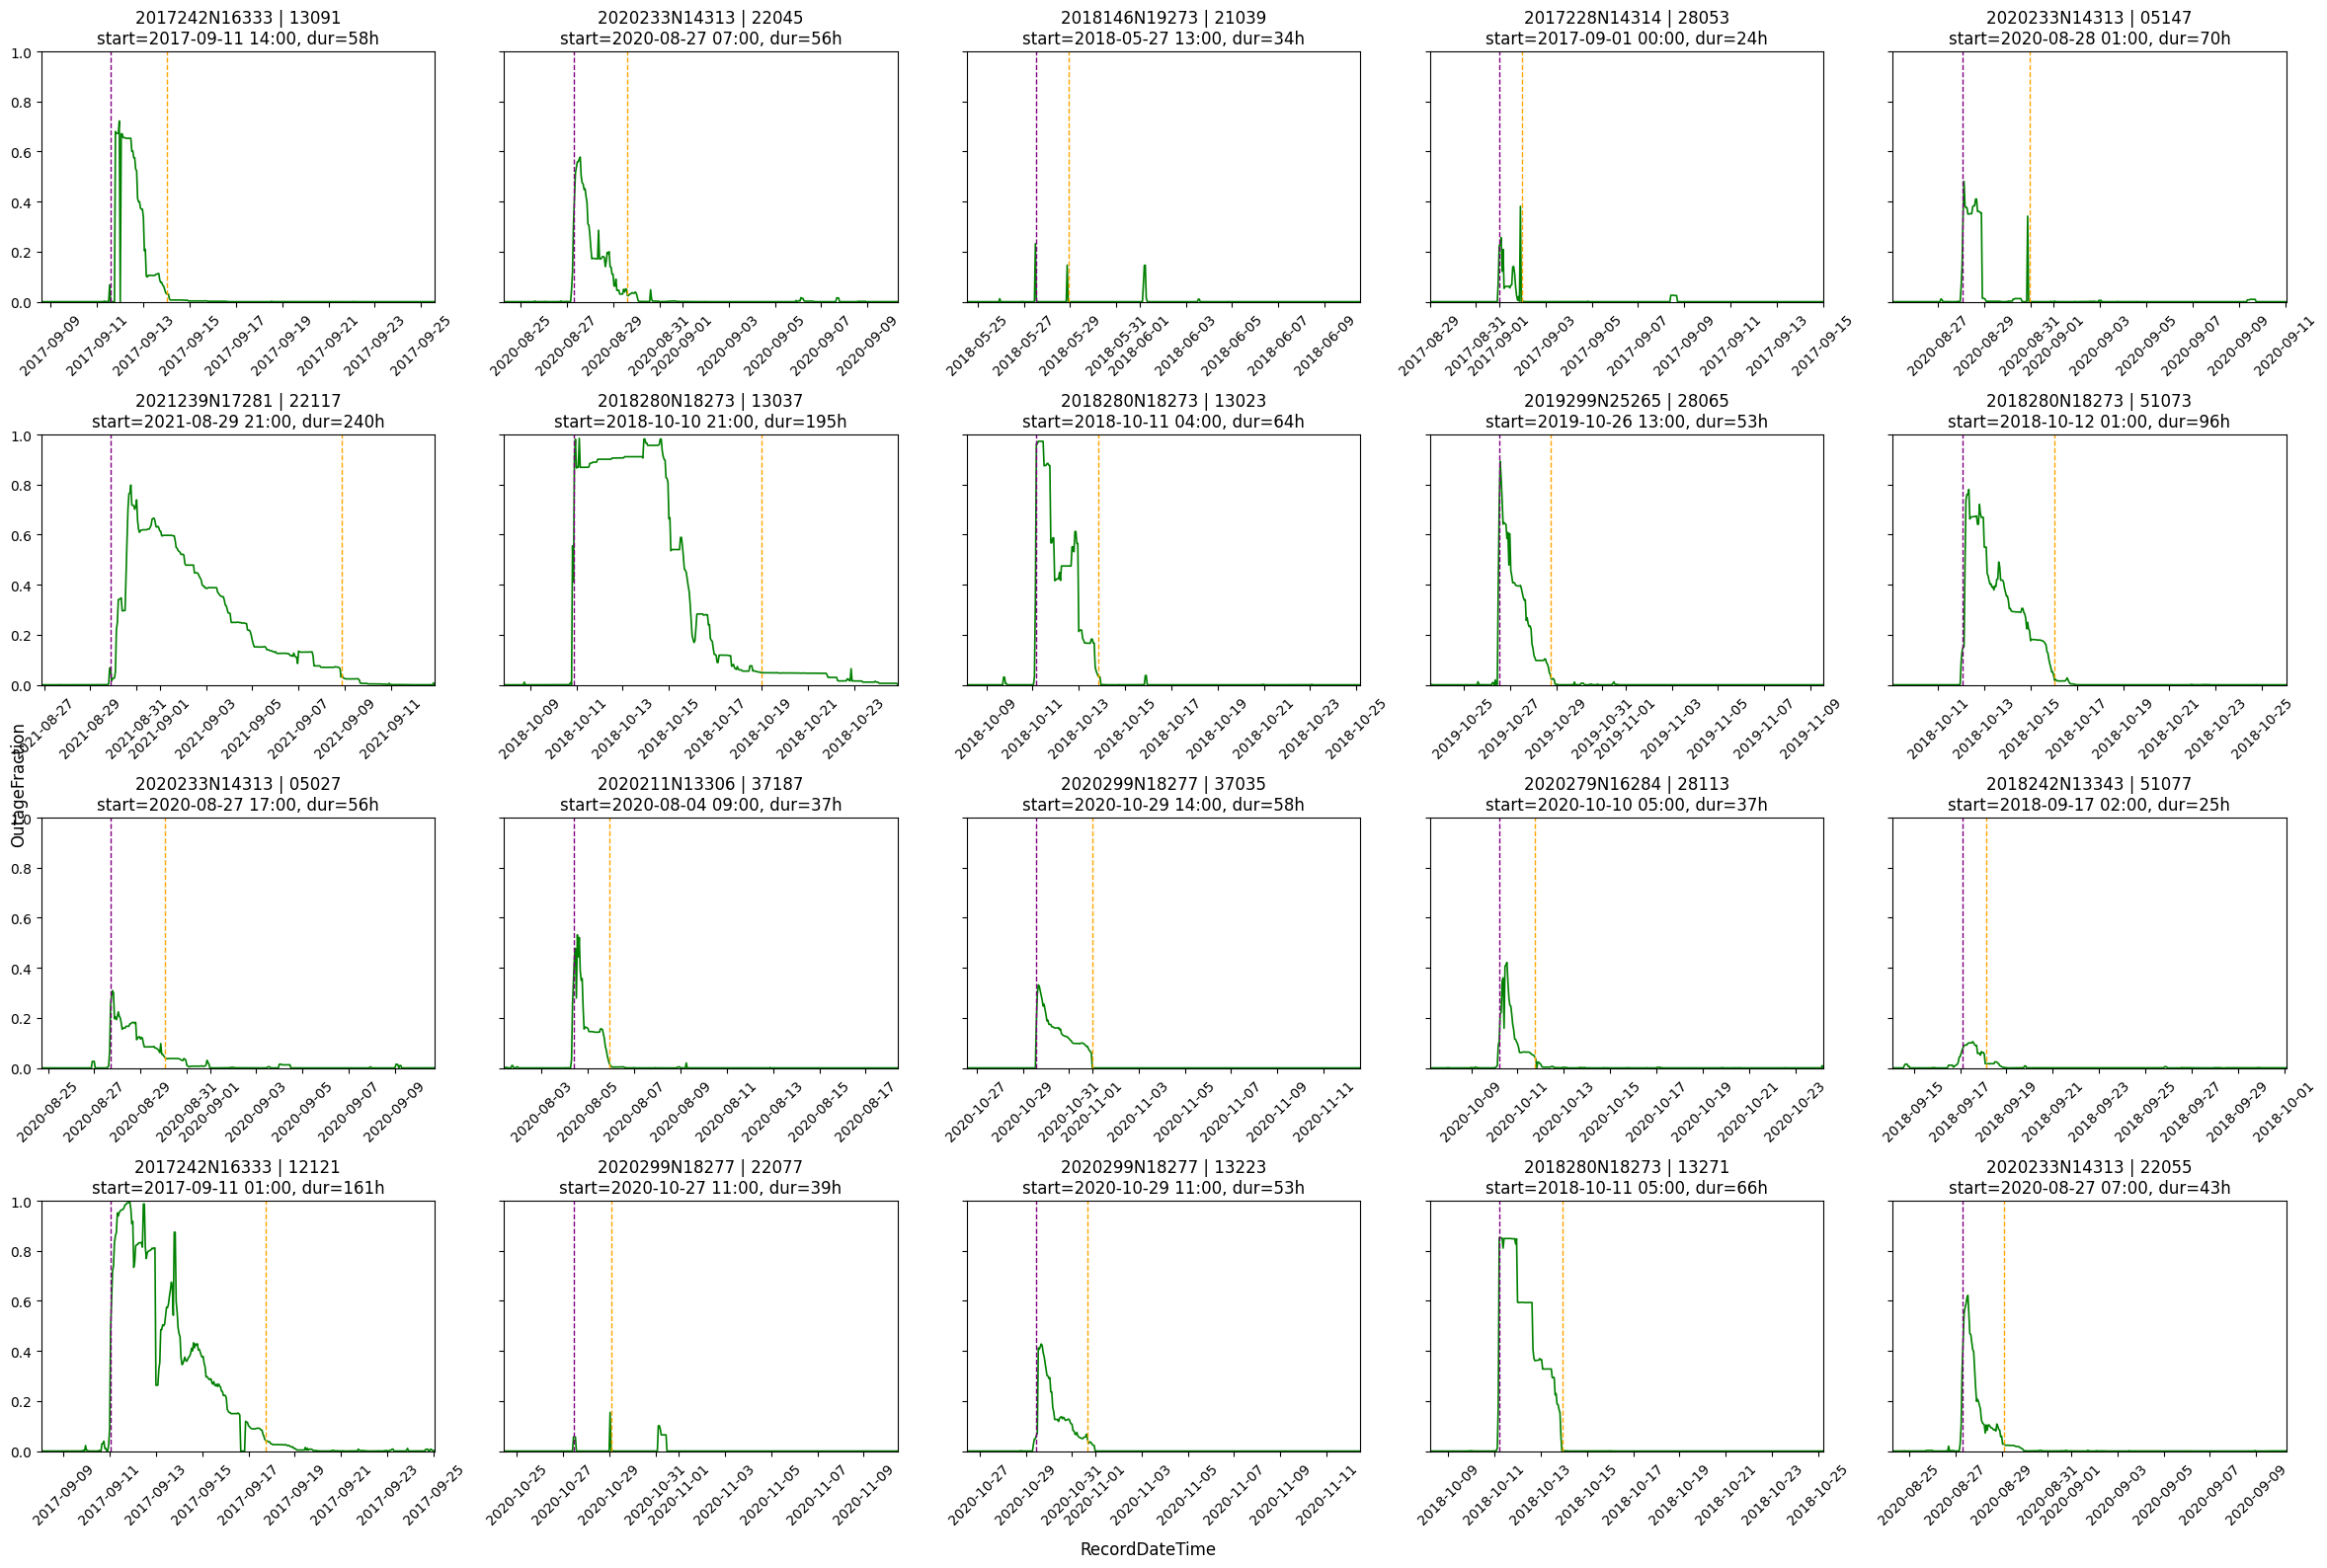


Plotted 20 county-event time series windows.


In [ ]:
# --- Cell 5: Plot 20 random time series windows (4 x 5 grid) ---

# Toggle window type:
#   "fixed" = plot a fixed time window after event start
#   "event" = plot only until the end of the event using POUS duration_hours
WINDOW_MODE = "fixed"   # change to "event" if you want to plot to the event end

# Fixed-window settings (used only when WINDOW_MODE == "fixed")
days_before = 3
days_after = 14

# Randomly sample 20 county-storm events to inspect
sample_events = pous.sample(n=20, random_state=42).reset_index(drop=True)

print("Random sample of 20 events:")
print(sample_events[["storm", "CountyFIPS", "event_start", "duration_hours"]].to_string(index=False))

fig, axes = plt.subplots(4, 5, figsize=(24, 16), sharey=True)
axes = axes.ravel()

for ax in axes:
    ax.set_visible(False)

n_plotted = 0

for ax, (_, row) in zip(axes, sample_events.iterrows()):
    county_fips = row["CountyFIPS"]
    event_start = row["event_start"]
    storm = row["storm"]
    duration_hours = row["duration_hours"]

    # Choose end of plotted window
    if WINDOW_MODE == "fixed":
        window_start = event_start - pd.Timedelta(days=days_before)
        window_end = event_start + pd.Timedelta(days=days_after)
    elif WINDOW_MODE == "event":
        window_start = event_start - pd.Timedelta(days=days_before)
        window_end = event_start + pd.Timedelta(hours=float(duration_hours))
    else:
        raise ValueError("WINDOW_MODE must be 'fixed' or 'event'.")

    g = load_time_series_window(
        county_fips=county_fips,
        event_start=event_start,
        days_before=days_before,
        days_after=(days_after if WINDOW_MODE == "fixed" else int(np.ceil(duration_hours / 24)) + 1),
    )

    ax.set_visible(True)
    ax.set_ylim(0.0, 1.0)
    ax.set_xlim(window_start, window_end)

    if g.empty:
        ax.set_title(f"{storm} | {county_fips}\n(no data returned)")
        continue

    # Plot outage fraction over time
    ax.plot(g["RecordDateTime"], g["OutageFraction"], color="green", linewidth=1.2)

    # Event start line
    ax.axvline(event_start, color="purple", linestyle="--", linewidth=1)

    # Event end line (based on POUS duration)
    event_end = event_start + pd.Timedelta(hours=float(duration_hours))
    ax.axvline(event_end, color="orange", linestyle="--", linewidth=1)

    ax.set_title(
        f"{storm} | {county_fips}\n"
        f"start={event_start.strftime('%Y-%m-%d %H:%M')}, dur={duration_hours:.0f}h"
    )
    ax.tick_params(axis="x", labelrotation=45)

    n_plotted += 1

fig.supylabel("OutageFraction")
fig.supxlabel("RecordDateTime")
plt.tight_layout()
plt.show()

print(f"\nPlotted {n_plotted} county-event time series windows.")

In [ ]:
# --- Cell 6: Build a CONUS sample source_df from the parquet time series ---

# This cell loads only 20 sampled county-storm windows from the large parquet file.
# It avoids reading the full ~160M-row file into memory.

import pandas as pd
import numpy as np

# Sample 20 event rows from POUS for inspection
sample_events = pous.sample(n=20, random_state=42).reset_index(drop=True)

print("Random sample of 20 POUS events:")
print(sample_events[["storm", "CountyFIPS", "event_start", "duration_hours"]].to_string(index=False))

def load_time_series_window(county_fips, event_start, days_before=3, days_after=14):
    """
    Load a small time window for one county directly from the parquet dataset.
    Returns a pandas DataFrame with:
      RecordDateTime, CountyFIPS, OutageFraction, CustomersTracked (if present)
    """
    event_start = pd.Timestamp(event_start)
    window_start = event_start - pd.Timedelta(days=days_before)
    window_end = event_start + pd.Timedelta(days=days_after)

    filt = (
        (ds.field("CountyFIPS") == county_fips) &
        (ds.field("RecordDateTime") >= window_start.to_pydatetime()) &
        (ds.field("RecordDateTime") <= window_end.to_pydatetime())
    )

    # Load only the columns we need for cleaning / plotting
    cols = ["RecordDateTime", "CountyFIPS", "OutageFraction", "CustomersTracked"]
    available_cols = [c for c in cols if c in ts_dataset.schema.names]

    table = ts_dataset.to_table(columns=available_cols, filter=filt)
    out = table.to_pandas()

    if out.empty:
        return out

    # Parquet may reconstruct index-like fields depending on how the file was written
    if "RecordDateTime" not in out.columns or "CountyFIPS" not in out.columns:
        out = out.reset_index()

    out["RecordDateTime"] = pd.to_datetime(out["RecordDateTime"])
    out["CountyFIPS"] = out["CountyFIPS"].astype(str).str.zfill(5)
    out = out.sort_values("RecordDateTime").reset_index(drop=True)

    return out

# Build a single inspection dataframe from the 20 sampled windows
pieces = []

for _, row in sample_events.iterrows():
    g = load_time_series_window(
        county_fips=row["CountyFIPS"],
        event_start=row["event_start"],
        days_before=3,
        days_after=14
    )

    if g.empty:
        continue

    # Add event metadata so the grouping logic matches the Florida notebook style
    g = g.copy()
    g["storm"] = row["storm"]
    g["event_start"] = pd.Timestamp(row["event_start"])
    g["duration_hours"] = row["duration_hours"]

    # Match the earlier convention: county + event_start
    g["event_id"] = g["CountyFIPS"].astype(str) + "_" + g["event_start"].dt.strftime("%Y-%m-%d %H:%M:%S")

    pieces.append(g)

source_df = pd.concat(pieces, ignore_index=True)

print("\nCombined sample source_df shape:", source_df.shape)
print(source_df.head())
print("\nColumns:")
print(source_df.columns.tolist())

Random sample of 20 POUS events:
        storm CountyFIPS         event_start  duration_hours
2017242N16333      13091 2017-09-11 14:00:00              58
2020233N14313      22045 2020-08-27 07:00:00              56
2018146N19273      21039 2018-05-27 13:00:00              34
2017228N14314      28053 2017-09-01 00:00:00              24
2020233N14313      05147 2020-08-28 01:00:00              70
2021239N17281      22117 2021-08-29 21:00:00             240
2018280N18273      13037 2018-10-10 21:00:00             195
2018280N18273      13023 2018-10-11 04:00:00              64
2019299N25265      28065 2019-10-26 13:00:00              53
2018280N18273      51073 2018-10-12 01:00:00              96
2020233N14313      05027 2020-08-27 17:00:00              56
2020211N13306      37187 2020-08-04 09:00:00              37
2020299N18277      37035 2020-10-29 14:00:00              58
2020279N16284      28113 2020-10-10 05:00:00              37
2018242N13343      51077 2018-09-17 02:00:00        

Redoing Cells 7 and 8 because somewhere in here, two FL storms are getting filtered out unnecessarily. Also, there was some redunancy in valid/invalid flagging.  

In [33]:
# --- Cell 7: Authoritative full-CONUS valid/invalid classification + cleaning helper ---
# - update on 19 May to add the buffers used in the FL-only cases

import numpy as np
import pandas as pd
from tqdm.auto import tqdm

# Same threshold rules used throughout
peak_thresh = 0.15
min_hours_above = 5

# Same cleaning parameters as the Florida notebook
med_window = 5
max_short_run = 3
abs_dev_thresh = 0.15
rel_dev_scale = 0.35

# Window buffer used for validity scoring
# Matches the old FL behaviour more closely:
# 12 hours before event_start, 11 hours after event_end
pad_before_hours = 12
pad_after_hours = 11

# Assumes `pous`, `ts_dataset`, and `ds` are already available in memory
pous = pous.copy()
pous["CountyFIPS"] = pous["CountyFIPS"].astype(str).str.zfill(5)
pous["event_start"] = pd.to_datetime(pous["event_start"])
pous["event_id"] = (
    pous["CountyFIPS"].astype(str) + "_" +
    pous["event_start"].dt.strftime("%Y-%m-%d %H:%M:%S")
)

def load_event_window_from_pq(county_fips, event_start, event_end, pad_before_hours=12, pad_after_hours=11):
    """
    Load a small county-event window directly from the parquet time series.
    This is used for the full-CONUS validity scan.

    Window semantics:
      [event_start - pad_before_hours, event_end + pad_after_hours]
    """
    event_start = pd.Timestamp(event_start)
    event_end = pd.Timestamp(event_end)

    window_start = event_start - pd.Timedelta(hours=pad_before_hours)
    window_end = event_end + pd.Timedelta(hours=pad_after_hours)

    filt = (
        (ds.field("CountyFIPS") == county_fips) &
        (ds.field("RecordDateTime") >= window_start.to_pydatetime()) &
        (ds.field("RecordDateTime") <= window_end.to_pydatetime())
    )

    table = ts_dataset.to_table(
        columns=["RecordDateTime", "CountyFIPS", "OutageFraction"],
        filter=filt
    )

    out = table.to_pandas()

    if out.empty:
        return out

    if "RecordDateTime" not in out.columns or "CountyFIPS" not in out.columns:
        out = out.reset_index()

    out["RecordDateTime"] = pd.to_datetime(out["RecordDateTime"])
    out["CountyFIPS"] = out["CountyFIPS"].astype(str).str.zfill(5)
    out = out.sort_values("RecordDateTime").reset_index(drop=True)

    return out

# Scan all CONUS POUS events and compute validity metrics
event_rows = []

for row in tqdm(pous.itertuples(index=False), total=len(pous), desc="Scanning CONUS POUS events"):
    county_fips = str(row.CountyFIPS).zfill(5)
    event_start = pd.Timestamp(row.event_start)
    duration_hours = float(row.duration_hours)
    event_end = event_start + pd.Timedelta(hours=duration_hours)

    g = load_event_window_from_pq(
        county_fips=county_fips,
        event_start=event_start,
        event_end=event_end,
        pad_before_hours=pad_before_hours,
        pad_after_hours=pad_after_hours
    )

    if g.empty:
        max_outage = np.nan
        hours_above_thresh = 0
        n_ts_points = 0
    else:
        s = g["OutageFraction"].astype(float).clip(0, 1)
        max_outage = float(s.max())
        hours_above_thresh = int((s > peak_thresh).sum())
        n_ts_points = int(len(g))

    event_rows.append({
        "event_id": row.event_id,
        "CountyFIPS": county_fips,
        "storm": row.storm,
        "event_start": event_start,
        "duration_hours": duration_hours,
        "max_outage": max_outage,
        "hours_above_thresh": hours_above_thresh,
        "n_ts_points": n_ts_points,
    })

event_metrics = pd.DataFrame(event_rows)

event_metrics["is_valid"] = (
    (event_metrics["max_outage"] >= peak_thresh) &
    (event_metrics["hours_above_thresh"] >= min_hours_above)
)

valid_df = event_metrics.loc[event_metrics["is_valid"], ["event_id", "CountyFIPS"]].copy()
rejected_events = event_metrics.loc[~event_metrics["is_valid"]].copy()

valid_keys = set(
    valid_df.itertuples(index=False, name=None)
)

print("Valid / invalid counts:")
print(event_metrics["is_valid"].value_counts(dropna=False))
print()
print("Summary:")
print(f"  Total event-county groups: {len(event_metrics)}")
print(f"  Valid event-county groups: {len(valid_df)}")
print(f"  Rejected event-county groups: {len(rejected_events)}")
print()
print("Metric summary:")
print(event_metrics[["max_outage", "hours_above_thresh", "n_ts_points"]].describe())

fl_mask = event_metrics["CountyFIPS"].str.startswith("12")
print("\nFlorida subset summary:")
print(f"  Raw Florida events: {int(fl_mask.sum())}")
print(f"  Valid Florida events: {int(event_metrics.loc[fl_mask, 'is_valid'].sum())}")
print(f"  Rejected Florida events: {int((~event_metrics.loc[fl_mask, 'is_valid']).sum())}")

print("\nTop rejected storms:")
if len(rejected_events) > 0:
    rejected_storms = (
        event_metrics[["event_id", "CountyFIPS", "storm"]]
        .drop_duplicates()
        .merge(rejected_events[["event_id", "CountyFIPS"]], on=["event_id", "CountyFIPS"], how="inner")
    )
    print(rejected_storms["storm"].value_counts().head(10))
else:
    print("None")

def clean_valid_outage_series(g):
    """
    Same cleaning logic as the Florida notebook:
    - 5-hour rolling median baseline
    - anomaly threshold based on absolute + relative deviation
    - interpolate only short anomalous runs
    - final 5-hour rolling median
    """
    g = g.sort_values("RecordDateTime").copy().reset_index(drop=True)
    s = g["OutageFraction"].astype(float).clip(0, 1)

    med = s.rolling(window=med_window, center=True, min_periods=1).median()

    dev = (s - med).abs()
    thresh = np.maximum(abs_dev_thresh, rel_dev_scale * med)
    anomaly = dev > thresh

    run_id = (anomaly != anomaly.shift()).cumsum()
    run_len = anomaly.groupby(run_id).transform("sum")
    short_anom = anomaly & (run_len <= max_short_run)

    repaired = s.mask(short_anom, np.nan)
    repaired_filled = repaired.copy()
    was_interpolated = pd.Series(False, index=g.index)

    run_id_np = run_id.to_numpy()
    short_run_ids = pd.unique(run_id[short_anom])

    for rid in short_run_ids:
        pos = np.flatnonzero(run_id_np == rid)
        if len(pos) == 0 or len(pos) > max_short_run:
            continue

        left = pos[0] - 1
        right = pos[-1] + 1
        if left < 0 or right >= len(g):
            continue

        left_val = repaired.iloc[left]
        right_val = repaired.iloc[right]
        if pd.isna(left_val) or pd.isna(right_val):
            continue

        repaired_filled.iloc[pos] = np.linspace(left_val, right_val, len(pos) + 2)[1:-1]
        was_interpolated.iloc[pos] = True

    cleaned = repaired_filled.rolling(window=med_window, center=True, min_periods=1).median()

    g["of_rolling_median"] = med
    g["of_anomaly"] = anomaly
    g["of_short_anomaly"] = short_anom
    g["outageFraction_repaired"] = repaired_filled
    g["outageFraction_clean"] = cleaned
    g["outage_clean"] = cleaned
    g["outageFraction_was_interpolated"] = was_interpolated

    return g

Scanning CONUS POUS events: 100%|██████████| 1040/1040 [01:08<00:00, 15.15it/s]

Valid / invalid counts:
is_valid
True     817
False    223
Name: count, dtype: int64

Summary:
  Total event-county groups: 1040
  Valid event-county groups: 817
  Rejected event-county groups: 223

Metric summary:
        max_outage  hours_above_thresh  n_ts_points
count  1040.000000         1040.000000  1040.000000
mean      0.537156           55.344231   113.707692
std       0.313671           83.112565    99.504640
min       0.051650            0.000000    48.000000
25%       0.256916            7.000000    61.750000
50%       0.480551           28.000000    83.000000
75%       0.841396           69.000000   122.250000
max       1.000000          594.000000   831.000000

Florida subset summary:
  Raw Florida events: 99
  Valid Florida events: 90
  Rejected Florida events: 9

Top rejected storms:
storm
2021239N17281    21
2018146N19273    19
2020233N14313    16
2020299N18277    15
2017228N14314    12
2020211N13306    12
2019192N29274    11
2021222N14301    11
2017242N16333    10
201

Random sample of 20 CONUS events:
        storm CountyFIPS         event_start  duration_hours
2017242N16333      13091 2017-09-11 14:00:00              58
2020233N14313      22045 2020-08-27 07:00:00              56
2018146N19273      21039 2018-05-27 13:00:00              34
2017228N14314      28053 2017-09-01 00:00:00              24
2020233N14313      05147 2020-08-28 01:00:00              70
2021239N17281      22117 2021-08-29 21:00:00             240
2018280N18273      13037 2018-10-10 21:00:00             195
2018280N18273      13023 2018-10-11 04:00:00              64
2019299N25265      28065 2019-10-26 13:00:00              53
2018280N18273      51073 2018-10-12 01:00:00              96
2020233N14313      05027 2020-08-27 17:00:00              56
2020211N13306      37187 2020-08-04 09:00:00              37
2020299N18277      37035 2020-10-29 14:00:00              58
2020279N16284      28113 2020-10-10 05:00:00              37
2018242N13343      51077 2018-09-17 02:00:00       

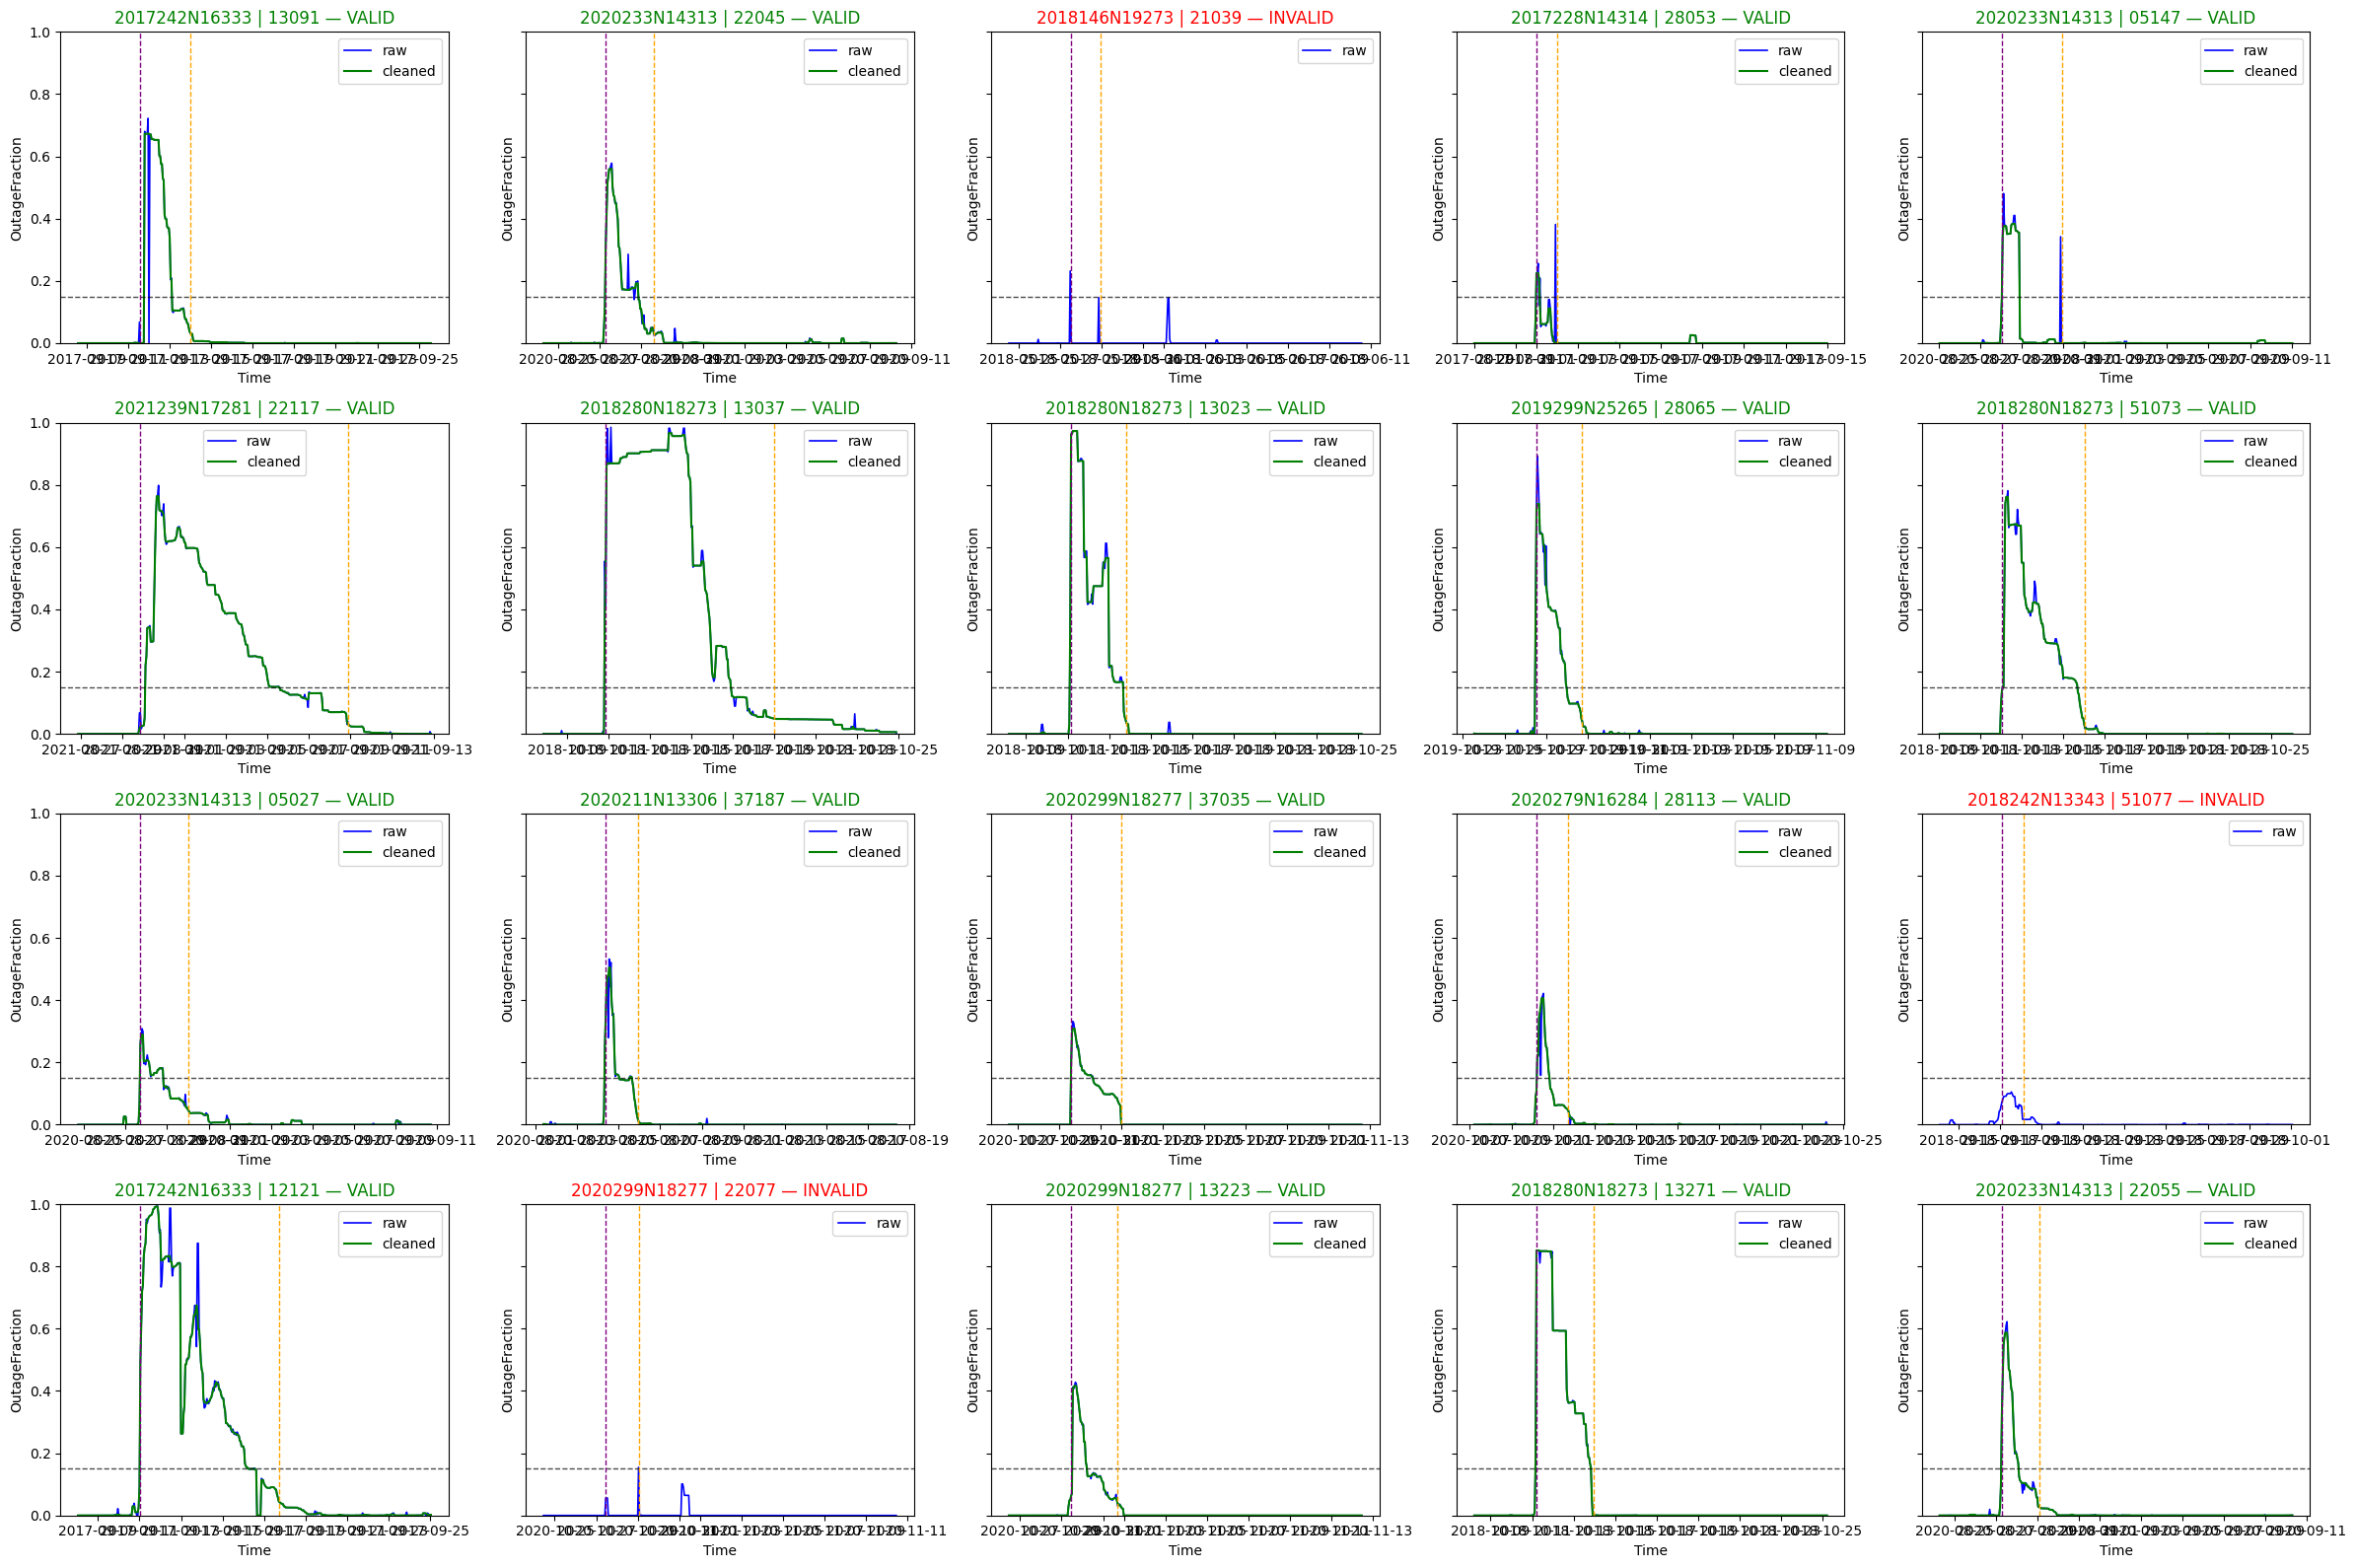

In [34]:
# --- Cell 8: Optional diagnostic plots for a random CONUS subset ---

import matplotlib.pyplot as plt

def load_time_series_window(county_fips, event_start, days_before=3, days_after=14):
    """
    Diagnostic helper for plotting a random subset.
    Loads a wider window around event_start.
    """
    event_start = pd.Timestamp(event_start)
    window_start = event_start - pd.Timedelta(days=days_before)
    window_end = event_start + pd.Timedelta(days=days_after)

    filt = (
        (ds.field("CountyFIPS") == county_fips) &
        (ds.field("RecordDateTime") >= window_start.to_pydatetime()) &
        (ds.field("RecordDateTime") <= window_end.to_pydatetime())
    )

    table = ts_dataset.to_table(
        columns=["RecordDateTime", "CountyFIPS", "OutageFraction"],
        filter=filt
    )

    out = table.to_pandas()

    if out.empty:
        return out

    if "RecordDateTime" not in out.columns or "CountyFIPS" not in out.columns:
        out = out.reset_index()

    out["RecordDateTime"] = pd.to_datetime(out["RecordDateTime"])
    out["CountyFIPS"] = out["CountyFIPS"].astype(str).str.zfill(5)
    out = out.sort_values("RecordDateTime").reset_index(drop=True)
    return out

sample_events = pous.sample(n=20, random_state=42).reset_index(drop=True)

print("Random sample of 20 CONUS events:")
print(sample_events[["storm", "CountyFIPS", "event_start", "duration_hours"]].to_string(index=False))

fig, axes = plt.subplots(4, 5, figsize=(24, 16), sharey=True)
axes = axes.ravel()

for ax in axes:
    ax.set_visible(False)

for ax, (_, row) in zip(axes, sample_events.iterrows()):
    event_id = row["event_id"]
    county_fips = row["CountyFIPS"]
    event_start = row["event_start"]
    storm = row["storm"]
    duration_hours = row["duration_hours"]

    g_raw = load_time_series_window(
        county_fips=county_fips,
        event_start=event_start,
        days_before=3,
        days_after=14
    )

    ax.set_visible(True)
    ax.set_ylim(0.0, 1.0)

    if g_raw.empty:
        ax.set_title(f"{storm} | {county_fips}\n(no data returned)")
        continue

    is_valid = (event_id, county_fips) in valid_keys
    label = "VALID" if is_valid else "INVALID"
    title_color = "green" if is_valid else "red"

    ax.plot(g_raw["RecordDateTime"], g_raw["OutageFraction"], color="blue", linewidth=1.2, label="raw")

    if is_valid:
        g_raw["event_start"] = pd.Timestamp(event_start)
        g_raw["duration_hours"] = float(duration_hours)
        g_clean = clean_valid_outage_series(g_raw)
        ax.plot(
            g_clean["RecordDateTime"],
            g_clean["outageFraction_clean"],
            color="green",
            linewidth=1.5,
            label="cleaned"
        )

    ax.axhline(peak_thresh, linestyle="--", linewidth=1, color="black", alpha=0.7)
    ax.axvline(event_start, color="purple", linestyle="--", linewidth=1)
    ax.axvline(event_start + pd.Timedelta(hours=float(duration_hours)), color="orange", linestyle="--", linewidth=1)

    ax.set_title(f"{storm} | {county_fips} — {label}", color=title_color)
    ax.set_xlabel("Time")
    ax.set_ylabel("OutageFraction")
    ax.legend(loc="best")

plt.tight_layout()
plt.show()

In [35]:
# --- Cell 10: Build CONUS t90 target table using the authoritative helpers from Cell 7 ---
# 19 May update to deal with redundancy

import pandas as pd
import numpy as np
from tqdm.auto import tqdm

# Assumes Cell 7 has already been run and these exist:
#   - pous
#   - load_event_window_from_pq
#   - clean_valid_outage_series
#   - last_downward_transition
#   - peak_thresh
#   - min_hours_above
#   - pad_before_hours
#   - pad_after_hours
#   - threshold (t90 threshold, expected to be 0.1)

required_names = [
    "pous",
    "load_event_window_from_pq",
    "clean_valid_outage_series",
    "last_downward_transition",
]
missing = [name for name in required_names if name not in globals()]
if missing:
    raise RuntimeError(f"Missing required objects from Cell 7: {missing}")

# Re-standardize POUS fields
pous = pous.copy()
pous["CountyFIPS"] = pous["CountyFIPS"].astype(str).str.zfill(5)
pous["event_start"] = pd.to_datetime(pous["event_start"])
pous["event_id"] = (
    pous["CountyFIPS"].astype(str) + "_" +
    pous["event_start"].dt.strftime("%Y-%m-%d %H:%M:%S")
)

t90_rows = []
rejected_rows = []

for row in tqdm(pous.itertuples(index=False), total=len(pous), desc="Building t90 targets"):
    county_fips = str(row.CountyFIPS).zfill(5)
    event_start = pd.Timestamp(row.event_start)
    duration_hours = float(row.duration_hours)
    event_end = event_start + pd.Timedelta(hours=duration_hours)

    g_raw = load_event_window_from_pq(
        county_fips=county_fips,
        event_start=event_start,
        event_end=event_end,
        pad_before_hours=pad_before_hours,
        pad_after_hours=pad_after_hours,
    )

    if g_raw.empty:
        rejected_rows.append({
            "event_id": row.event_id,
            "CountyFIPS": county_fips,
            "storm": row.storm,
            "event_start": event_start,
            "event_end": event_end,
            "duration_hours": duration_hours,
            "reason": "no_time_series_data",
        })
        continue

    g_raw["event_start"] = event_start
    g_raw["duration_hours"] = duration_hours

    s_raw = g_raw["OutageFraction"].astype(float).clip(0, 1)
    max_outage = float(s_raw.max())
    hours_above_thresh = int((s_raw > peak_thresh).sum())
    n_ts_points = int(len(g_raw))

    is_valid = (max_outage >= peak_thresh) and (hours_above_thresh >= min_hours_above)

    if not is_valid:
        rejected_rows.append({
            "event_id": row.event_id,
            "CountyFIPS": county_fips,
            "storm": row.storm,
            "event_start": event_start,
            "event_end": event_end,
            "duration_hours": duration_hours,
            "max_outage": max_outage,
            "hours_above_thresh": hours_above_thresh,
            "n_ts_points": n_ts_points,
            "reason": "invalid_event",
        })
        continue

    g_clean = clean_valid_outage_series(g_raw)
    cross_time_90, t90_val, cens90 = last_downward_transition(g_clean, threshold=threshold)

    t90_rows.append({
        "event_id": row.event_id,
        "CountyFIPS": county_fips,
        "storm": row.storm,
        "event_start": event_start,
        "event_end": event_end,
        "duration_hours": duration_hours,
        "year": int(row.year),
        "month": int(row.month),
        "county_pop": int(row.county_pop),
        "pre_outage_tracked_customers": float(row.pre_outage_tracked_customers),
        "days_since_data_start": float(row.days_since_data_start),
        "n_periods": int(row.n_periods),
        "integral": float(row.integral),
        "pop_hours_supply_lost": float(row.pop_hours_supply_lost),
        "max_outage_raw": max_outage,
        "hours_above_thresh_raw": hours_above_thresh,
        "n_ts_points": n_ts_points,
        "is_valid": True,
        "t90_lastcross": t90_val,
        "censored_lastcross": cens90,
        "crossing_time_lastcross": cross_time_90,
    })

t90_targets = pd.DataFrame(t90_rows)
rejected_events = pd.DataFrame(rejected_rows)

print("t90 target table shape:", t90_targets.shape)
print("Rejected events shape:", rejected_events.shape)

print("\nValid event summary:")
print(t90_targets["t90_lastcross"].describe())

print("\nCensored fraction:")
print(t90_targets["censored_lastcross"].mean())

print("\nRejected by reason:")
if not rejected_events.empty:
    print(rejected_events["reason"].value_counts())
else:
    print("None")

print("\nFlorida subset summary:")
fl_valid = t90_targets["CountyFIPS"].str.startswith("12").sum()
fl_rejected = rejected_events["CountyFIPS"].str.startswith("12").sum()
fl_total = fl_valid + fl_rejected
print(f"  Raw Florida events: {fl_total}")
print(f"  Valid Florida events: {fl_valid}")
print(f"  Rejected Florida events: {fl_rejected}")

print("\nProblem event check:")
for eid in ["12075_2017-07-30 21:00:00", "12051_2021-07-04 07:00:00", "12029_2021-07-06 00:00:00"]:
    print(f"\n{eid}")
    print("  in valid:", eid in set(t90_targets["event_id"]))
    print("  in rejected:", eid in set(rejected_events["event_id"]))

Building t90 targets:   0%|          | 0/1040 [00:00<?, ?it/s]

Building t90 targets: 100%|██████████| 1040/1040 [01:48<00:00,  9.59it/s]

t90 target table shape: (817, 21)
Rejected events shape: (223, 10)

Valid event summary:
count    817.000000
mean      84.359255
std       97.497127
min        1.885185
25%       29.917038
50%       55.013793
75%       98.176366
max      680.559693
Name: t90_lastcross, dtype: float64

Censored fraction:
0.0

Rejected by reason:
reason
invalid_event    223
Name: count, dtype: int64

Florida subset summary:
  Raw Florida events: 99
  Valid Florida events: 90
  Rejected Florida events: 9

Problem event check:

12075_2017-07-30 21:00:00
  in valid: True
  in rejected: False

12051_2021-07-04 07:00:00
  in valid: False
  in rejected: True

12029_2021-07-06 00:00:00
  in valid: True
  in rejected: False


^ that above logic was taken from *filtering_of.ipynb* 
- The below t90 target construction logic was taken from *regression5.ipynb*

In [ ]:
# --- Cell 11 (was 12): Save a versioned master base dataset for later feature expansion ---

# This is the traceable event-level base table:
# - one row per valid county-event
# - includes POUS metadata
# - includes t90 target
# - ready for later feature merges (GDP, distance, infrastructure, etc.)

master_base = t90_targets.merge(
    pous.drop(columns=["event_id"]),  # avoid duplicate event_id from the original POUS table
    on=["CountyFIPS", "storm", "event_start", "duration_hours", "year", "month",
        "county_pop", "pre_outage_tracked_customers", "days_since_data_start",
        "n_periods", "integral", "pop_hours_supply_lost"],
    how="left",
    suffixes=("", "_pous")
)

print("Master base shape:", master_base.shape)
print(master_base.head())

# Save outputs
base_path = r"C:\Users\teaching\Downloads\outage-recovery-forecasting\data_transients\event_level_master_base_t90_conus.csv"
rejected_path = r"C:\Users\teaching\Downloads\outage-recovery-forecasting\data_transients\rejected_events_t90_conus.csv"

master_base.to_csv(base_path, index=False)
rejected_events.to_csv(rejected_path, index=False)

print("\nSaved master base to:")
print(base_path)

print("\nSaved rejected events to:")
print(rejected_path)

Master base shape: (817, 22)
                    event_id CountyFIPS          storm         event_start  \
0  54059_2017-06-24 04:00:00      54059  2017171N24271 2017-06-24 04:00:00   
1  12075_2017-07-30 21:00:00      12075  2017212N28275 2017-07-30 21:00:00   
2  48355_2017-08-25 21:00:00      48355  2017228N14314 2017-08-25 21:00:00   
3  48391_2017-08-25 22:00:00      48391  2017228N14314 2017-08-25 22:00:00   
4  48409_2017-08-25 22:00:00      48409  2017228N14314 2017-08-25 22:00:00   

            event_end  duration_hours  year  month  county_pop  \
0 2017-06-26 18:00:00            62.0  2017      6       22573   
1 2017-08-03 11:00:00            86.0  2017      7       45260   
2 2017-09-04 22:00:00           241.0  2017      8      351674   
3 2017-09-11 23:00:00           409.0  2017      8        6632   
4 2017-09-07 01:00:00           291.0  2017      8       69954   

   pre_outage_tracked_customers  ...    integral  pop_hours_supply_lost  \
0                       13970.

In [38]:
print("POUS columns:", pous.columns.tolist())
print("POUS dtypes:\n", pous.dtypes)
print("POUS head:\n", pous.head(1).T)

POUS columns: ['event_start', 'CountyFIPS', 'county_pop', 'pre_outage_tracked_customers', 'days_since_data_start', 'duration_hours', 'n_periods', 'integral', 'pop_hours_supply_lost', 'storm', 'duration_days', 'year', 'month', 'event_id']
POUS dtypes:
 event_start                     datetime64[us]
CountyFIPS                                 str
county_pop                               int64
pre_outage_tracked_customers           float64
days_since_data_start                  float64
duration_hours                           int64
n_periods                                int64
integral                               float64
pop_hours_supply_lost                  float64
storm                                      str
duration_days                          float64
year                                     int64
month                                    int64
event_id                                   str
dtype: object
POUS head:
                                                       0
event_st

In [39]:
print("g_raw shape:", g_raw.shape)
print("g_raw columns:", g_raw.columns.tolist())
print("g_raw dtypes:\n", g_raw.dtypes)
print("g_raw head:\n", g_raw.head())
print("g_raw index:", type(g_raw.index), getattr(g_raw.index, "names", None))

g_raw shape: (81, 5)
g_raw columns: ['RecordDateTime', 'CountyFIPS', 'OutageFraction', 'event_start', 'duration_hours']
g_raw dtypes:
 RecordDateTime    datetime64[ns]
CountyFIPS                   str
OutageFraction           float64
event_start       datetime64[us]
duration_hours           float64
dtype: object
g_raw head:
        RecordDateTime CountyFIPS  OutageFraction         event_start  \
0 2022-09-30 14:00:00      51590        0.000000 2022-10-01 02:00:00   
1 2022-09-30 15:00:00      51590        0.000000 2022-10-01 02:00:00   
2 2022-09-30 16:00:00      51590        0.002267 2022-10-01 02:00:00   
3 2022-09-30 17:00:00      51590        0.003779 2022-10-01 02:00:00   
4 2022-09-30 18:00:00      51590        0.003563 2022-10-01 02:00:00   

   duration_hours  
0            57.0  
1            57.0  
2            57.0  
3            57.0  
4            57.0  
g_raw index: <class 'pandas.RangeIndex'> [None]


In [40]:
print("After adding metadata columns:")
print(g_raw[["event_start", "duration_hours"]].head())

After adding metadata columns:
          event_start  duration_hours
0 2022-10-01 02:00:00            57.0
1 2022-10-01 02:00:00            57.0
2 2022-10-01 02:00:00            57.0
3 2022-10-01 02:00:00            57.0
4 2022-10-01 02:00:00            57.0


In [41]:
print("ts_dataset schema names:", ts_dataset.schema.names)

ts_dataset schema names: ['OutageFraction', 'CustomersTracked', 'RecordDateTime', 'CountyFIPS']


Now adding t50, using logic from *adding_t50.ipynb* (which was only for Florida, but should be generalizable to CONUS)

In [50]:
# --- Cell 12 (was 13): Add t50 to the CONUS event-level target table ---

import pandas as pd
import numpy as np
from tqdm.auto import tqdm

# Build t50 from the already-built valid t90 target table
base_events = (
    t90_targets[["event_id", "CountyFIPS", "storm", "event_start", "event_end", "duration_hours"]]
    .drop_duplicates()
    .copy()
)

t50_rows = []

for _, row in tqdm(base_events.iterrows(), total=len(base_events), desc="Building t50 targets"):
    county_fips = str(row["CountyFIPS"]).zfill(5)
    event_start = pd.Timestamp(row["event_start"])
    event_end = pd.Timestamp(row["event_end"])
    duration_hours = float(row["duration_hours"])

    g_raw = load_event_window_from_pq(county_fips, event_start, event_end)
    if g_raw.empty:
        t50_rows.append({
            "event_id": row["event_id"],
            "CountyFIPS": county_fips,
            "t50": np.nan,
            "t50_censored": 1,
            "peak_outage_clean_t50": np.nan,
            "threshold_used_t50": np.nan,
            "crossing_time_t50": pd.NaT,
        })
        continue

    g_raw["event_start"] = event_start
    g_raw["duration_hours"] = duration_hours

    g_clean = clean_valid_outage_series(g_raw)

    post = g_clean[g_clean["RecordDateTime"] >= event_start].copy()
    peak = post["outage_clean"].max()

    if pd.isna(peak) or peak <= 0:
        t50 = np.nan
        cens50 = 1
        cross_time_50 = pd.NaT
        threshold_50 = np.nan
    else:
        threshold_50 = 0.5 * float(peak)
        cross_time_50, t50, cens50 = last_downward_transition(g_clean, threshold=threshold_50)

    t50_rows.append({
        "event_id": row["event_id"],
        "CountyFIPS": county_fips,
        "t50": t50,
        "t50_censored": cens50,
        "peak_outage_clean_t50": float(peak) if pd.notna(peak) else np.nan,
        "threshold_used_t50": threshold_50,
        "crossing_time_t50": cross_time_50,
    })

t50_df = pd.DataFrame(t50_rows)

print("t50 table shape:", t50_df.shape)
print(t50_df.head().to_string(index=False))

# Merge onto t90_targets
targets_df = t90_targets.merge(
    t50_df,
    on=["event_id", "CountyFIPS"],
    how="left"
)

print("\nMerged target table shape:", targets_df.shape)
print(targets_df[[
    "event_id", "CountyFIPS", "t90_lastcross", "t50", "peak_outage_clean_t50"
]].head().to_string(index=False))

print("\nMissing t50 count:", targets_df["t50"].isna().sum())
print("t50 censored fraction:", targets_df["t50_censored"].mean())

Building t50 targets: 100%|██████████| 817/817 [01:32<00:00,  8.84it/s]

t50 table shape: (817, 7)
                 event_id CountyFIPS        t50  t50_censored  peak_outage_clean_t50  threshold_used_t50             crossing_time_t50
54059_2017-06-24 04:00:00      54059  11.359080             0               0.471510            0.235755 2017-06-24 15:21:32.688679245
12075_2017-07-30 21:00:00      12075   1.500000             0               0.870968            0.435484 2017-07-30 22:30:00.000000000
48355_2017-08-25 21:00:00      48355  76.333549             0               0.732856            0.366428 2017-08-29 01:20:00.775694893
48391_2017-08-25 22:00:00      48391 260.913793             0               0.989056            0.494528 2017-09-05 18:54:49.655172413
48409_2017-08-25 22:00:00      48409 122.136965             0               0.906812            0.453406 2017-08-31 00:08:13.072448439

Merged target table shape: (849, 26)
                 event_id CountyFIPS  t90_lastcross        t50  peak_outage_clean_t50
54059_2017-06-24 04:00:00      54059    

^ It means that about 1.42% of the valid county-event cases did not cross below the t50 threshold within the observed time window, so t50 was treated as censored for those events. This is not great, and it stems from the fact that t90 is using an absolute threshold (10% of customers still out), which is more likely to be crossed than a relative threshold like 50% of the peak outage. **This should likely be changed in the future.**

[edit: seems like that's no longer true with the post-event_end buffer i added!]

To extract the weather data in GEE, I need a csv like FL_POUS.csv but for CONUS. 


In [44]:
# --- Cell 14: Build CONUS_POUS.csv from the raw POUS event table ---
# Input: raw POUS event table
pous_path = r"C:\Users\teaching\Downloads\outage-recovery-forecasting\data_raw\POUS.csv"
# Output: CONUS POUS event table to upload **as a GEE asset**
save_path = r"C:\Users\teaching\Downloads\outage-recovery-forecasting\data_transients\CONUS_POUS.csv"

import pandas as pd


# Load raw POUS
pous = pd.read_csv(pous_path)

# Standardize key fields
pous["CountyFIPS"] = pous["CountyFIPS"].astype(str).str.zfill(5)
pous["event_start"] = pd.to_datetime(pous["event_start"])

# Recreate event_id if needed, but keep the same convention used before
if "event_id" not in pous.columns:
    pous["event_id"] = (
        pous["CountyFIPS"].astype(str) + "_" +
        pous["event_start"].dt.strftime("%Y-%m-%d %H:%M:%S")
    )

# Ensure the output uses the same column order as the Florida file
wanted_cols = [
    "event_start",
    "CountyFIPS",
    "county_pop",
    "pre_outage_tracked_customers",
    "days_since_data_start",
    "duration_hours",
    "n_periods",
    "integral",
    "pop_hours_supply_lost",
    "storm",
    "duration_days",
    "year",
    "month",
    "event_id",
]

missing = [c for c in wanted_cols if c not in pous.columns]
if missing:
    raise KeyError(f"Missing expected columns in POUS table: {missing}")

conus_pous = pous[wanted_cols].copy()

# Save
conus_pous.to_csv(save_path, index=False)

print("Saved CONUS_POUS.csv to:")
print(save_path)
print("\nShape:", conus_pous.shape)
print("\nHead:")
print(conus_pous.head().to_string(index=False))

Saved CONUS_POUS.csv to:
C:\Users\teaching\Downloads\outage-recovery-forecasting\data_transients\CONUS_POUS.csv

Shape: (1040, 14)

Head:
        event_start CountyFIPS  county_pop  pre_outage_tracked_customers  days_since_data_start  duration_hours  n_periods  integral  pop_hours_supply_lost         storm  duration_days  year  month                  event_id
2017-06-21 16:00:00      54001       15414                        6599.0             171.625000              47         47  0.389301           6.000692e+03 2017171N24271       1.958333  2017      6 54001_2017-06-21 16:00:00
2017-06-24 04:00:00      54059       22573                       13970.0             174.125000              62         62  4.778789           1.078716e+05 2017171N24271       2.583333  2017      6 54059_2017-06-24 04:00:00
2017-07-30 21:00:00      12075       45260                        2942.7             210.833333              86         86  4.007550           1.813817e+05 2017212N28275       3.583333  2017

(Made conus_pilot_gee_era5.js to extract the weather data for CONUS, using the input CSV above.) 

The output from that GEE pilot script is at data_transients\conus_pous_era5_hourly_pilot.csv . 

In [45]:
# check the pilot script to see if that worked okay.
import pandas as pd

fl_path = r"C:\Users\teaching\Downloads\outage-recovery-forecasting\data_transients\florida_all_events_era5_hourly.csv"
conus_path = r"C:\Users\teaching\Downloads\outage-recovery-forecasting\data_transients\conus_pous_era5_hourly_pilot.csv"

fl = pd.read_csv(fl_path, nrows=5)
conus = pd.read_csv(conus_path, nrows=5)

print("Florida columns:")
print(fl.columns.tolist())

print("\nCONUS columns:")
print(conus.columns.tolist())

print("\nShared columns only:")
shared = [c for c in fl.columns if c in conus.columns]
print(shared)

print("\nFlorida sample:")
print(fl.head().to_string(index=False))

print("\nCONUS sample:")
print(conus.head().to_string(index=False))

Florida columns:
['system:index', 'county', 'datetime', 'duration_hours', 'event_id', 'event_start', 'geoid', 'gust_mps', 'precip_mm', 'pressure_hpa', 'storm', 'temp_c', 'wind_speed_mps', '.geo']

CONUS columns:
['system:index', 'county', 'datetime', 'duration_hours', 'event_id', 'event_start', 'geoid', 'gust_mps', 'precip_mm', 'pressure_hpa', 'storm', 'temp_c', 'wind_speed_mps', '.geo']

Shared columns only:
['system:index', 'county', 'datetime', 'duration_hours', 'event_id', 'event_start', 'geoid', 'gust_mps', 'precip_mm', 'pressure_hpa', 'storm', 'temp_c', 'wind_speed_mps', '.geo']

Florida sample:
                    system:index county         datetime  duration_hours                  event_id         event_start  geoid  gust_mps  precip_mm  pressure_hpa         storm    temp_c  wind_speed_mps                                   .geo
00000000000000000000_20170730T09   Levy 2017-07-30 09:00              86 12075_2017-07-30 21:00:00 2017-07-30 21:00:00  12075  9.834633   1.732711   10

^ Seems to have worked fine!

So, now for the full data export rather than just a pilot snippet. GEE code in conus_full_gee_era5.js . This produced *data_transients\conus_pous_era5_hourly.csv* .

In [46]:
# Cell 15: --- Build the first CONUS event-level base dataset ---

import pandas as pd
import numpy as np

# Paths
weather_path = r"C:\Users\teaching\Downloads\outage-recovery-forecasting\data_transients\conus_pous_era5_hourly.csv"
pous_path = r"C:\Users\teaching\Downloads\outage-recovery-forecasting\data_transients\CONUS_POUS.csv"

out_parquet_path = r"C:\Users\teaching\Downloads\outage-recovery-forecasting\data_transients\event_level_dataset_conus_base_weather.parquet"
out_csv_path = r"C:\Users\teaching\Downloads\outage-recovery-forecasting\data_transients\event_level_dataset_conus_base_weather.csv"

# Load inputs
weather = pd.read_csv(weather_path)
pous = pd.read_csv(pous_path)

# Standardize types
weather["CountyFIPS"] = weather["geoid"].astype(str).str.zfill(5)
weather["datetime"] = pd.to_datetime(weather["datetime"])
weather["event_start"] = pd.to_datetime(weather["event_start"])

pous["CountyFIPS"] = pous["CountyFIPS"].astype(str).str.zfill(5)
pous["event_start"] = pd.to_datetime(pous["event_start"])

if "event_id" not in pous.columns:
    pous["event_id"] = pous["CountyFIPS"].astype(str) + "_" + pous["event_start"].dt.strftime("%Y-%m-%d %H:%M:%S")

# Clean weather table a little
keep_weather_cols = [
    "event_id",
    "CountyFIPS",
    "county",
    "datetime",
    "event_start",
    "duration_hours",
    "gust_mps",
    "precip_mm",
    "pressure_hpa",
    "temp_c",
    "wind_speed_mps",
]
keep_weather_cols = [c for c in keep_weather_cols if c in weather.columns]
weather = weather[keep_weather_cols].copy()

# Weather aggregation logic:
# - sort by time
# - use the whole event unless it is longer than 7 days
# - if longer than 7 days, use the first 168 hourly rows
def build_weather_features(g):
    g = g.sort_values("datetime").copy()
    window = g.head(168) if len(g) >= 168 else g

    return pd.Series({
        "county": g["county"].iloc[0] if "county" in g.columns else np.nan,
        "max_gust": window["gust_mps"].max(),
        "mean_gust_7d": window["gust_mps"].mean(),
        "total_precip_7d": window["precip_mm"].sum(),
        "pressure_min_7d": window["pressure_hpa"].min(),
        "weather_hours_available": len(g),
        "weather_hours_used": len(window),
    })

weather_features = (
    weather.groupby(["event_id", "CountyFIPS"])
    .apply(build_weather_features)
    .reset_index()
)

print("Weather feature table shape:", weather_features.shape)
print(weather_features.head().to_string(index=False))

# Merge features onto the POUS event table
base_df = pous.merge(
    weather_features,
    on=["event_id", "CountyFIPS"],
    how="left"
)

# Optional column ordering to keep things readable and close to the Florida structure
preferred_cols = [
    "event_id",
    "storm",
    "CountyFIPS",
    "county",
    "event_start",
    "duration_hours",
    "county_pop",
    "pre_outage_tracked_customers",
    "days_since_data_start",
    "n_periods",
    "integral",
    "pop_hours_supply_lost",
    "duration_days",
    "year",
    "month",
    "max_gust",
    "mean_gust_7d",
    "total_precip_7d",
    "pressure_min_7d",
    "weather_hours_available",
    "weather_hours_used",
]

preferred_cols = [c for c in preferred_cols if c in base_df.columns]
other_cols = [c for c in base_df.columns if c not in preferred_cols]
base_df = base_df[preferred_cols + other_cols].copy()

print("\nBase dataset shape:", base_df.shape)
print("\nMissing weather features:")
print(base_df[["max_gust", "mean_gust_7d", "total_precip_7d", "pressure_min_7d"]].isna().sum())

print("\nHead:")
print(base_df.head().to_string(index=False))

# Save intermediate dataset
base_df.to_parquet(out_parquet_path, index=False)
base_df.to_csv(out_csv_path, index=False)

print("\nSaved parquet to:")
print(out_parquet_path)

print("\nSaved csv to:")
print(out_csv_path)

Weather feature table shape: (1022, 9)
                 event_id CountyFIPS  county  max_gust  mean_gust_7d  total_precip_7d  pressure_min_7d  weather_hours_available  weather_hours_used
01001_2020-10-29 06:00:00      01001 Autauga 34.406995      9.152431        34.580874       995.734743                       90                  90
01003_2020-09-16 01:00:00      01003 Baldwin 30.505209     12.056865       320.442242       990.240484                      236                 168
01005_2017-09-11 16:00:00      01005 Barbour 22.971888     12.149543        76.569629       995.844003                       54                  54
01005_2018-10-10 23:00:00      01005 Barbour 20.606758      9.953236        69.177830       992.014883                       66                  66
01007_2020-10-29 07:00:00      01007    Bibb 21.787489      8.830640        48.619395       991.010477                       89                  89

Base dataset shape: (1040, 21)

Missing weather features:
max_gust      

Merge the new weather-base table with the target table on event_id and CountyFIPS, which includes t90 and t50.

Saved csv to:
***C:\Users\teaching\Downloads\outage-recovery-forecasting\data_transients\event_level_dataset_conus_base_weather.csv***

Next: adding min_distance. Using logic from *RF_v2.ipynb*

In [57]:
# --- Cell 16: Load a clean base master_df checkpoint for IBTrACS / GDP steps ---

import os
import pandas as pd
import numpy as np

# Use the pre-target, pre-IBTrACS base weather table
base_candidates = [
    r"C:\Users\teaching\Downloads\outage-recovery-forecasting\data_transients\event_level_dataset_conus_base_weather.parquet",
    r"C:\Users\teaching\Downloads\outage-recovery-forecasting\data_transients\event_level_dataset_conus_base_weather.csv",
]

base_path = next((p for p in base_candidates if os.path.exists(p)), None)
if base_path is None:
    raise FileNotFoundError(
        "Could not find the CONUS base weather checkpoint. "
        "Expected event_level_dataset_conus_base_weather.parquet or .csv"
    )

if base_path.endswith(".parquet"):
    master_df = pd.read_parquet(base_path)
else:
    master_df = pd.read_csv(base_path)

print("Loaded base checkpoint:", base_path)
print("Initial shape:", master_df.shape)

# Standardize key columns
master_df["CountyFIPS"] = master_df["CountyFIPS"].astype(str).str.zfill(5)
master_df["event_start"] = pd.to_datetime(master_df["event_start"], errors="coerce")

# Promote canonical column names if only suffixed versions exist
canonical_bases = [
    "storm",
    "event_start",
    "duration_hours",
    "year",
    "month",
    "county_pop",
    "pre_outage_tracked_customers",
    "days_since_data_start",
    "n_periods",
    "integral",
    "pop_hours_supply_lost",
]

for base in canonical_bases:
    if base not in master_df.columns:
        for suffix in ("_x", "_y"):
            candidate = f"{base}{suffix}"
            if candidate in master_df.columns:
                master_df[base] = master_df[candidate]
                break

# Drop any merge suffix columns so later cells start cleanly
suffix_cols = [c for c in master_df.columns if c.endswith("_x") or c.endswith("_y")]

# Drop later-stage features if present accidentally
later_stage_cols = [
    "min_dist_to_storm_km",
    "matched_ibtracs_storm",
    "storm_max_wind_center_in_conus_mps",
    "storm_max_wind_near_conus_mps",
    "county_gdp_real_2017_dollars",
    "county_gdp_real_2017_per_capita",
    "t90",
    "t50",
    "t90_lastcross",
    "censored_lastcross",
    "crossing_time_lastcross",
    "t50_censored",
    "threshold_used_t50",
    "crossing_time_t50",
]

drop_cols = [c for c in (suffix_cols + later_stage_cols) if c in master_df.columns]
if drop_cols:
    master_df = master_df.drop(columns=drop_cols)

# Sanity checks for the base stage only
required_cols = [
    "event_id",
    "storm",
    "CountyFIPS",
    "event_start",
    "duration_hours",
    "county_pop",
    "max_gust",
    "mean_gust_7d",
    "total_precip_7d",
    "pressure_min_7d",
]
missing = [c for c in required_cols if c not in master_df.columns]
if missing:
    raise KeyError(f"Missing required columns after loading base master_df: {missing}")

print("\nCleaned master_df shape:", master_df.shape)
print("\nKey columns:")
print(master_df[[
    "event_id", "storm", "CountyFIPS", "event_start", "duration_hours"
]].head().to_string(index=False))

print("\nColumns containing 'event' or 'storm':")
print([c for c in master_df.columns if ("event" in c.lower() or "storm" in c.lower())])

Loaded base checkpoint: C:\Users\teaching\Downloads\outage-recovery-forecasting\data_transients\event_level_dataset_conus_base_weather.parquet
Initial shape: (1040, 21)

Cleaned master_df shape: (1040, 21)

Key columns:
                 event_id         storm CountyFIPS         event_start  duration_hours
54001_2017-06-21 16:00:00 2017171N24271      54001 2017-06-21 16:00:00              47
54059_2017-06-24 04:00:00 2017171N24271      54059 2017-06-24 04:00:00              62
12075_2017-07-30 21:00:00 2017212N28275      12075 2017-07-30 21:00:00              86
21055_2017-08-24 22:00:00 2017228N14314      21055 2017-08-24 22:00:00              52
48355_2017-08-25 21:00:00 2017228N14314      48355 2017-08-25 21:00:00             241

Columns containing 'event' or 'storm':
['event_id', 'storm', 'event_start']


In [58]:
# --- Cell 17: Compute min distance to IBTrACS storm track and merge onto master_df ---

# Create a fast lookup for county centroids
centroid_lookup = county_centroids.set_index("CountyFIPS")[["centroid_lat", "centroid_lon"]].to_dict("index")

distances = []
matched_ib_storms = []

# Use event_start from the master table
master_df = master_df.copy()
master_df["event_start"] = pd.to_datetime(master_df["event_start"])
master_df["CountyFIPS"] = master_df["CountyFIPS"].astype(str).str.zfill(5)

for row in tqdm(master_df.itertuples(index=False), total=len(master_df), desc="Computing IBTrACS distance"):
    county_fips = str(row.CountyFIPS).zfill(5)
    event_time = pd.Timestamp(row.event_start)

    # County centroid
    centroid = centroid_lookup.get(county_fips)
    if centroid is None:
        distances.append(np.nan)
        matched_ib_storms.append(None)
        continue

    county_latlon = (centroid["centroid_lat"], centroid["centroid_lon"])

    # Time window around event start, same logic as before
    window = ib[
        (ib["ISO_TIME"] >= event_time - pd.Timedelta(hours=48)) &
        (ib["ISO_TIME"] <= event_time + pd.Timedelta(hours=48))
    ].dropna(subset=["lat", "lon"])

    if window.empty:
        distances.append(np.nan)
        matched_ib_storms.append(None)
        continue

    # Minimum geodesic distance to any track point in the window
    dists = [
        geodesic(county_latlon, (r.lat, r.lon)).km
        for r in window.itertuples(index=False)
    ]

    min_idx = int(np.argmin(dists))
    distances.append(float(dists[min_idx]))
    matched_ib_storms.append(window.iloc[min_idx]["storm_id_ib"])

master_df["min_dist_to_storm_km"] = distances
master_df["matched_ibtracs_storm"] = matched_ib_storms

print("Distance summary:")
print(master_df["min_dist_to_storm_km"].describe())

print("\nMissing distance count:", master_df["min_dist_to_storm_km"].isna().sum())
print("\nMatched IBTrACS storms:", master_df["matched_ibtracs_storm"].nunique(dropna=True))

# Save updated master table
out_parquet_path = r"C:\Users\teaching\Downloads\outage-recovery-forecasting\data_transients\event_level_dataset_conus_master_with_ibtracs.parquet"
out_csv_path = r"C:\Users\teaching\Downloads\outage-recovery-forecasting\data_transients\event_level_dataset_conus_master_with_ibtracs.csv"

master_df.to_parquet(out_parquet_path, index=False)
master_df.to_csv(out_csv_path, index=False)

print("\nSaved updated master table to:")
print(out_parquet_path)
print(out_csv_path)

Computing IBTrACS distance: 100%|██████████| 1040/1040 [00:33<00:00, 31.11it/s]

Distance summary:
count      914.000000
mean       121.401911
std        503.151410
min          2.537105
25%         46.535637
50%         78.778196
75%        119.320977
max      14002.263855
Name: min_dist_to_storm_km, dtype: float64

Missing distance count: 126

Matched IBTrACS storms: 37

Saved updated master table to:
C:\Users\teaching\Downloads\outage-recovery-forecasting\data_transients\event_level_dataset_conus_master_with_ibtracs.parquet
C:\Users\teaching\Downloads\outage-recovery-forecasting\data_transients\event_level_dataset_conus_master_with_ibtracs.csv


^ That seemed to work. Next is adding GDP data, which was initially done in *RF_v4.ipynb* . 

In [59]:
# Cell 18: --- Load BEA GDP, reshape to county-year, and merge onto the CONUS master table ---

import pandas as pd
import numpy as np

gdp_path = r"C:\Users\teaching\Downloads\outage-recovery-forecasting\data_raw\CAGDP1\CAGDP1__ALL_AREAS_2001_2024.csv"

# Assumes master_df already exists in memory from the previous steps
# If not, load the saved master parquet before running this cell.

gdp_raw = pd.read_csv(gdp_path, encoding="latin1")

print("Raw GDP shape:", gdp_raw.shape)
print(gdp_raw.columns.tolist())
print(gdp_raw.head().to_string(index=False))

# Clean GDP table
gdp = gdp_raw.copy()

gdp["CountyFIPS"] = (
    gdp["GeoFIPS"]
    .astype(str)
    .str.replace('"', "", regex=False)
    .str.strip()
)

# Keep only county-level FIPS:
# - exactly 5 digits
# - not national total (00000)
# - not state totals (e.g. 01000, 12000)
gdp = gdp[gdp["CountyFIPS"].str.fullmatch(r"\d{5}", na=False)].copy()
gdp = gdp[gdp["CountyFIPS"] != "00000"].copy()
gdp = gdp[~gdp["CountyFIPS"].str.endswith("000")].copy()

# Keep only real GDP rows
gdp = gdp[gdp["LineCode"] == 1].copy()

print("After county + LineCode filter:")
print(gdp[["CountyFIPS", "GeoName", "LineCode", "Description"]].head().to_string(index=False))
print("Remaining rows:", len(gdp))

# Identify year columns
year_cols = [c for c in gdp.columns if str(c).isdigit()]
print("\nYear columns found:", year_cols[:5], "...", year_cols[-5:])

# Wide -> long
id_vars = [c for c in ["CountyFIPS", "GeoName", "Description", "Unit"] if c in gdp.columns]

gdp_long = gdp.melt(
    id_vars=id_vars,
    value_vars=year_cols,
    var_name="year",
    value_name="county_gdp_real_2017_thousand_dollars"
)

gdp_long["year"] = gdp_long["year"].astype(int)

# Clean numeric values
gdp_long["county_gdp_real_2017_thousand_dollars"] = (
    gdp_long["county_gdp_real_2017_thousand_dollars"]
    .astype(str)
    .str.replace(",", "", regex=False)
    .str.strip()
)

gdp_long["county_gdp_real_2017_thousand_dollars"] = pd.to_numeric(
    gdp_long["county_gdp_real_2017_thousand_dollars"],
    errors="coerce"
)

# Convert thousands of chained 2017 dollars -> dollars
gdp_long["county_gdp_real_2017_dollars"] = (
    gdp_long["county_gdp_real_2017_thousand_dollars"] * 1000
)

gdp_clean = gdp_long[["CountyFIPS", "year", "county_gdp_real_2017_dollars"]].dropna().copy()

print("\nClean GDP shape:", gdp_clean.shape)
print(gdp_clean.head().to_string(index=False))
print("Year range:", gdp_clean["year"].min(), "to", gdp_clean["year"].max())

# Merge onto master_df by county-year
master_df = master_df.copy()
master_df["CountyFIPS"] = master_df["CountyFIPS"].astype(str).str.zfill(5)

if "year" not in master_df.columns:
    master_df["year"] = pd.to_datetime(master_df["event_start"]).dt.year

master_df = master_df.merge(
    gdp_clean,
    on=["CountyFIPS", "year"],
    how="left"
)

print("\nMissing GDP rows:", master_df["county_gdp_real_2017_dollars"].isna().sum())

if master_df["county_gdp_real_2017_dollars"].isna().any():
    print(
        master_df.loc[
            master_df["county_gdp_real_2017_dollars"].isna(),
            ["event_id", "CountyFIPS", "year", "storm"]
        ].drop_duplicates().head(20).to_string(index=False)
    )

# GDP per capita
master_df["county_gdp_real_2017_per_capita"] = (
    master_df["county_gdp_real_2017_dollars"] / master_df["county_pop"]
)

print("\nGDP summary:")
print(master_df[[
    "county_gdp_real_2017_dollars",
    "county_gdp_real_2017_per_capita"
]].describe())

print("\nHead:")
print(master_df[[
    "event_id",
    "CountyFIPS",
    "year",
    "county_pop",
    "county_gdp_real_2017_dollars",
    "county_gdp_real_2017_per_capita"
]].head().to_string(index=False))

# Save updated master table
out_parquet_path = r"C:\Users\teaching\Downloads\outage-recovery-forecasting\data_transients\event_level_dataset_conus_master_with_gdp.parquet"
out_csv_path = r"C:\Users\teaching\Downloads\outage-recovery-forecasting\data_transients\event_level_dataset_conus_master_with_gdp.csv"

master_df.to_parquet(out_parquet_path, index=False)
master_df.to_csv(out_csv_path, index=False)

print("\nSaved updated master table to:")
print(out_parquet_path)
print(out_csv_path)

Raw GDP shape: (9565, 32)
['GeoFIPS', 'GeoName', 'Region', 'TableName', 'LineCode', 'IndustryClassification', 'Description', 'Unit', '2001', '2002', '2003', '2004', '2005', '2006', '2007', '2008', '2009', '2010', '2011', '2012', '2013', '2014', '2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023', '2024']
 GeoFIPS       GeoName Region TableName  LineCode IndustryClassification                                        Description                              Unit        2001        2002        2003        2004        2005        2006        2007        2008        2009        2010        2011        2012        2013        2014        2015        2016        2017        2018        2019        2020        2021        2022        2023        2024
 "00000" United States           CAGDP1       1.0                    ...      Real GDP (thousands of chained 2017 dollars)  Thousands of chained 2017 dollars 14230726000 14472712000 14877312000 15449757000 15987957000 16433148000

Saved updated master table to:
C:\Users\teaching\Downloads\outage-recovery-forecasting\data_transients\event_level_dataset_conus_master_with_gdp.parquet
C:\Users\teaching\Downloads\outage-recovery-forecasting\data_transients\event_level_dataset_conus_master_with_gdp.csv


Realized i forgot to add the storm track max wind:

In [60]:
# Cell 19: --- Add IBTrACS distance + storm severity features to the CONUS master table ---

import pandas as pd
import numpy as np
import geopandas as gpd
from geopy.distance import geodesic
from tqdm.auto import tqdm

master_path = r"C:\Users\teaching\Downloads\outage-recovery-forecasting\data_transients\event_level_dataset_conus_master_with_gdp.parquet"

master_df = pd.read_parquet(master_path)

# Standardize types
master_df["CountyFIPS"] = master_df["CountyFIPS"].astype(str).str.zfill(5)
master_df["event_start"] = pd.to_datetime(master_df["event_start"])

print("Loaded master_df shape:", master_df.shape)
print(master_df.columns.tolist())
print(master_df.head().to_string(index=False))


# Paths
ib_path = r"C:\Users\teaching\Downloads\outage-recovery-forecasting\data_raw\ibtracs_conus_subset.csv"

# # Assumes master_df already exists from the CONUS master build step
# master_df = master_df.copy()
# master_df["CountyFIPS"] = master_df["CountyFIPS"].astype(str).str.zfill(5)
# master_df["event_start"] = pd.to_datetime(master_df["event_start"])

# ------------------------------------------------------------
# 1) Load and clean IBTrACS
# ------------------------------------------------------------
ib = pd.read_csv(ib_path, low_memory=False)

ib = ib[["SID", "ISO_TIME", "LAT", "LON", "USA_WIND"]].copy()
ib["ISO_TIME"] = pd.to_datetime(ib["ISO_TIME"], errors="coerce")
ib = ib.dropna(subset=["ISO_TIME"])

ib["lat"] = pd.to_numeric(ib["LAT"], errors="coerce")
ib["lon"] = pd.to_numeric(ib["LON"], errors="coerce")
ib["wind_knots"] = pd.to_numeric(ib["USA_WIND"], errors="coerce")
ib["wind_mps"] = ib["wind_knots"] * 0.514444
ib = ib.rename(columns={"SID": "storm_id_ib"})
ib["year"] = ib["ISO_TIME"].dt.year

# Keep only years that appear in the master table
master_years = pd.to_datetime(master_df["event_start"]).dt.year.unique()
ib = ib[ib["year"].isin(master_years)].copy()

print("IBTrACS rows after year filter:", len(ib))
print("IBTrACS storms after year filter:", ib["storm_id_ib"].nunique())
print(ib.head().to_string(index=False))

# ------------------------------------------------------------
# 2) Build CONUS county centroids and CONUS land geometry
# ------------------------------------------------------------
county_fips_needed = master_df["CountyFIPS"].astype(str).str.zfill(5).unique()

counties = gpd.read_file(
    "https://www2.census.gov/geo/tiger/TIGER2020/COUNTY/tl_2020_us_county.zip"
)

counties["CountyFIPS"] = counties["STATEFP"] + counties["COUNTYFP"]

# Keep lower 48 + DC only
exclude_state_fips = {"02", "15", "60", "66", "69", "72", "78"}
counties = counties[~counties["STATEFP"].isin(exclude_state_fips)].copy()

# Keep only counties that appear in the master table
counties = counties[counties["CountyFIPS"].isin(county_fips_needed)].copy()

# Project to equal-area CRS for centroid and buffer work
counties_5070 = counties.to_crs("EPSG:5070")
conus_geom_5070 = counties_5070.unary_union

# County centroids in WGS84 for geodesic distance
centroids_5070 = counties_5070.geometry.centroid
centroids_wgs84 = gpd.GeoSeries(centroids_5070, crs="EPSG:5070").to_crs("EPSG:4326")

county_centroids = pd.DataFrame({
    "CountyFIPS": counties_5070["CountyFIPS"].values,
    "centroid_lat": centroids_wgs84.y.values,
    "centroid_lon": centroids_wgs84.x.values,
})

print("\nCounty centroids shape:", county_centroids.shape)
print(county_centroids.head().to_string(index=False))

# Fast centroid lookup
centroid_lookup = county_centroids.set_index("CountyFIPS")[["centroid_lat", "centroid_lon"]].to_dict("index")

# ------------------------------------------------------------
# 3) Match each event to IBTrACS and compute min distance
# ------------------------------------------------------------
MATCH_WINDOW_HOURS = 48

distances = []
matched_ibtracs_storms = []

for row in tqdm(master_df.itertuples(index=False), total=len(master_df), desc="Matching IBTrACS"):
    county_fips = str(row.CountyFIPS).zfill(5)
    event_time = pd.Timestamp(row.event_start)

    centroid = centroid_lookup.get(county_fips)
    if centroid is None:
        distances.append(np.nan)
        matched_ibtracs_storms.append(None)
        continue

    county_latlon = (centroid["centroid_lat"], centroid["centroid_lon"])

    window = ib[
        (ib["ISO_TIME"] >= event_time - pd.Timedelta(hours=MATCH_WINDOW_HOURS)) &
        (ib["ISO_TIME"] <= event_time + pd.Timedelta(hours=MATCH_WINDOW_HOURS))
    ].copy()

    if window.empty:
        distances.append(np.nan)
        matched_ibtracs_storms.append(None)
        continue

    dists = [
        geodesic(county_latlon, (r.lat, r.lon)).km
        for r in window.itertuples(index=False)
    ]

    min_idx = int(np.argmin(dists))
    distances.append(float(dists[min_idx]))
    matched_ibtracs_storms.append(window.iloc[min_idx]["storm_id_ib"])

master_df["min_dist_to_storm_km"] = distances
master_df["matched_ibtracs_storm"] = matched_ibtracs_storms

print("\nDistance summary:")
print(master_df["min_dist_to_storm_km"].describe())
print("\nMissing distance count:", master_df["min_dist_to_storm_km"].isna().sum())

# ------------------------------------------------------------
# 4) Compute storm_max_wind_near_conus_mps
# ------------------------------------------------------------
CONUS_BUFFER_KM = 250
CONUS_BUFFER_M = CONUS_BUFFER_KM * 1000

ib_gdf = gpd.GeoDataFrame(
    ib.copy(),
    geometry=gpd.points_from_xy(ib["lon"], ib["lat"]),
    crs="EPSG:4326"
).to_crs("EPSG:5070")

ib_gdf["center_in_conus"] = ib_gdf.geometry.within(conus_geom_5070)

conus_buffer_5070 = gpd.GeoSeries([conus_geom_5070], crs="EPSG:5070").buffer(CONUS_BUFFER_M).iloc[0]
ib_gdf["near_conus"] = ib_gdf.geometry.within(conus_buffer_5070)

near_max = (
    ib_gdf[ib_gdf["near_conus"]]
    .groupby("storm_id_ib")["wind_mps"]
    .max()
    .reset_index()
    .rename(columns={"wind_mps": "storm_max_wind_near_conus_mps"})
)

strict_max = (
    ib_gdf[ib_gdf["center_in_conus"]]
    .groupby("storm_id_ib")["wind_mps"]
    .max()
    .reset_index()
    .rename(columns={"wind_mps": "storm_max_wind_center_in_conus_mps"})
)

master_df = master_df.merge(
    strict_max,
    left_on="matched_ibtracs_storm",
    right_on="storm_id_ib",
    how="left"
).drop(columns=["storm_id_ib"], errors="ignore")

master_df = master_df.merge(
    near_max,
    left_on="matched_ibtracs_storm",
    right_on="storm_id_ib",
    how="left"
).drop(columns=["storm_id_ib"], errors="ignore")

print("\nWind feature summary:")
print(master_df[[
    "storm",
    "matched_ibtracs_storm",
    "storm_max_wind_center_in_conus_mps",
    "storm_max_wind_near_conus_mps"
]].drop_duplicates().head(20).to_string(index=False))

print("\nMissing strict CONUS max wind:", master_df["storm_max_wind_center_in_conus_mps"].isna().sum())
print("Missing near-CONUS max wind:", master_df["storm_max_wind_near_conus_mps"].isna().sum())

# ------------------------------------------------------------
# 5) Save updated master table
# ------------------------------------------------------------
out_parquet_path = r"C:\Users\teaching\Downloads\outage-recovery-forecasting\data_transients\event_level_dataset_conus_master_final.parquet"
out_csv_path = r"C:\Users\teaching\Downloads\outage-recovery-forecasting\data_transients\event_level_dataset_conus_master_final.csv"

master_df.to_parquet(out_parquet_path, index=False)
master_df.to_csv(out_csv_path, index=False)

print("\nSaved updated master table to:")
print(out_parquet_path)
print(out_csv_path)

Loaded master_df shape: (1040, 25)
['event_id', 'storm', 'CountyFIPS', 'county', 'event_start', 'duration_hours', 'county_pop', 'pre_outage_tracked_customers', 'days_since_data_start', 'n_periods', 'integral', 'pop_hours_supply_lost', 'duration_days', 'year', 'month', 'max_gust', 'mean_gust_7d', 'total_precip_7d', 'pressure_min_7d', 'weather_hours_available', 'weather_hours_used', 'min_dist_to_storm_km', 'matched_ibtracs_storm', 'county_gdp_real_2017_dollars', 'county_gdp_real_2017_per_capita']
                 event_id         storm CountyFIPS     county         event_start  duration_hours  county_pop  pre_outage_tracked_customers  days_since_data_start  n_periods  integral  pop_hours_supply_lost  duration_days  year  month  max_gust  mean_gust_7d  total_precip_7d  pressure_min_7d  weather_hours_available  weather_hours_used  min_dist_to_storm_km matched_ibtracs_storm  county_gdp_real_2017_dollars  county_gdp_real_2017_per_capita
54001_2017-06-21 16:00:00 2017171N24271      54001    B

C:\Users\teaching\AppData\Local\Temp\ipykernel_11888\4060734397.py:36: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  ib["ISO_TIME"] = pd.to_datetime(ib["ISO_TIME"], errors="coerce")


IBTrACS rows after year filter: 37686
IBTrACS storms after year filter: 666
  storm_id_ib            ISO_TIME     LAT     LON USA_WIND     lat     lon  wind_knots  wind_mps  year
2017008N08128 2017-01-07 12:00:00 7.90000 127.800       20 7.90000 127.800        20.0 10.288880  2017
2017008N08128 2017-01-07 15:00:00 8.13752 127.655       20 8.13752 127.655        20.0 10.288880  2017
2017008N08128 2017-01-07 18:00:00 8.40000 127.500       20 8.40000 127.500        20.0 10.288880  2017
2017008N08128 2017-01-07 21:00:00 8.69997 127.322       22 8.69997 127.322        22.0 11.317768  2017
2017008N08128 2017-01-08 00:00:00 9.00000 127.100       25 9.00000 127.100        25.0 12.861100  2017


C:\Users\teaching\AppData\Local\Temp\ipykernel_11888\4060734397.py:74: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  conus_geom_5070 = counties_5070.unary_union



County centroids shape: (675, 3)
CountyFIPS  centroid_lat  centroid_lon
     01027     33.269045    -85.860679
     42007     40.682148    -80.349355
     28061     32.019073    -89.118888
     37037     35.702612    -79.255396
     01091     32.247491    -87.789619


Matching IBTrACS: 100%|██████████| 1040/1040 [00:35<00:00, 29.53it/s]



Distance summary:
count     1040.000000
mean       137.728643
std        490.938428
min          2.537105
25%         47.669326
50%         82.985355
75%        125.039067
max      14002.263855
Name: min_dist_to_storm_km, dtype: float64

Missing distance count: 0

Wind feature summary:
        storm matched_ibtracs_storm  storm_max_wind_center_in_conus_mps  storm_max_wind_near_conus_mps
2017171N24271         2017171N24271                            23.14998                       25.72220
2017212N28275         2017212N28275                            25.72220                       25.72220
2017228N14314         2017228N14314                            59.16106                       59.16106
2017240N31279         2017240N31279                            20.57776                       20.57776
2017242N16333         2017242N16333                            51.44440                       59.16106
2017242N16333         2017247N09327                                 NaN                       

I believe that is the end of data compilation! Next is to actually run the modelling, in *CONUS_modelling*.

Saved updated master table to:
C:\Users\teaching\Downloads\outage-recovery-forecasting\data_transients\event_level_dataset_conus_master_final.parquet
C:\Users\teaching\Downloads\outage-recovery-forecasting\data_transients\event_level_dataset_conus_master_final.csv

Not sure why the master is back up to 1040 rows, and why it hasn't included t90 and t50. trying to merge them on now

In [61]:
# --- Cell 20: Attach t90/t50 targets, create final master table, and save outputs ---

import pandas as pd
import numpy as np

# Assumes `master_df` is the clean 1040-row feature table from Cell 19
if "master_df" not in globals():
    raise RuntimeError("master_df is not in memory. Run Cells 16-19 first.")

# Build or use the target table
if "targets_df" in globals():
    target_source = targets_df.copy()
elif "t90_targets" in globals() and "t50_df" in globals():
    target_source = t90_targets.merge(
        t50_df,
        on=["event_id", "CountyFIPS"],
        how="left"
    )
else:
    raise RuntimeError(
        "No target table found. Need either targets_df, or both t90_targets and t50_df."
    )

# Keep only target-related columns so we do not create duplicate feature columns
target_keep = [
    "event_id",
    "CountyFIPS",
    "t90_lastcross",
    "censored_lastcross",
    "crossing_time_lastcross",
    "t50",
    "t50_censored",
    "peak_outage_clean_t50",
    "threshold_used_t50",
    "crossing_time_t50",
    "max_outage_raw",
    "hours_above_thresh_raw",
    "n_ts_points",
    "is_valid",
]
target_keep = [c for c in target_keep if c in target_source.columns]
targets_small = target_source[target_keep].copy()

# Standardize keys
master_df = master_df.copy()
master_df["CountyFIPS"] = master_df["CountyFIPS"].astype(str).str.zfill(5)
targets_small["CountyFIPS"] = targets_small["CountyFIPS"].astype(str).str.zfill(5)

# Merge targets onto the full feature table, preserving all rows
final_df = master_df.merge(
    targets_small,
    on=["event_id", "CountyFIPS"],
    how="left"
)

# Compatibility columns for modelling notebooks
final_df["t90"] = final_df["t90_lastcross"]
final_df["t90_censored"] = final_df["censored_lastcross"]

# Keep a common peak column for compatibility
if "peak_outage_clean" not in final_df.columns and "peak_outage_clean_t50" in final_df.columns:
    final_df["peak_outage_clean"] = final_df["peak_outage_clean_t50"]
elif "peak_outage_clean" in final_df.columns and "peak_outage_clean_t50" in final_df.columns:
    final_df["peak_outage_clean"] = final_df["peak_outage_clean"].fillna(final_df["peak_outage_clean_t50"])

# Build the valid modeling subset
master_valid_df = final_df.dropna(subset=["t90", "t50"]).copy()

print("Final full table shape:", final_df.shape)
print("Valid modeling subset shape:", master_valid_df.shape)

print("\nFlorida summary in full table:")
fl_mask = final_df["CountyFIPS"].str.startswith("12")
print("  Florida rows total:", int(fl_mask.sum()))
print("  Florida rows with t90:", int(final_df.loc[fl_mask, "t90"].notna().sum()))
print("  Florida rows with t50:", int(final_df.loc[fl_mask, "t50"].notna().sum()))

print("\nTarget summary:")
print(final_df[["t90", "t50"]].isna().sum())

print("\nHead of final table:")
print(final_df[[
    "event_id", "storm", "CountyFIPS", "event_start", "duration_hours", "t90", "t50"
]].head().to_string(index=False))

# Save outputs
out_full_parquet = r"C:\Users\teaching\Downloads\outage-recovery-forecasting\data_transients\event_level_dataset_conus_master_final.parquet"
out_full_csv = r"C:\Users\teaching\Downloads\outage-recovery-forecasting\data_transients\event_level_dataset_conus_master_final.csv"

out_valid_parquet = r"C:\Users\teaching\Downloads\outage-recovery-forecasting\data_transients\event_level_dataset_conus_modeling_valid.parquet"
out_valid_csv = r"C:\Users\teaching\Downloads\outage-recovery-forecasting\data_transients\event_level_dataset_conus_modeling_valid.csv"

final_df.to_parquet(out_full_parquet, index=False)
final_df.to_csv(out_full_csv, index=False)

master_valid_df.to_parquet(out_valid_parquet, index=False)
master_valid_df.to_csv(out_valid_csv, index=False)

print("\nSaved full table to:")
print(out_full_parquet)
print(out_full_csv)

print("\nSaved valid modeling subset to:")
print(out_valid_parquet)
print(out_valid_csv)

Final full table shape: (1136, 42)
Valid modeling subset shape: (913, 42)

Florida summary in full table:
  Florida rows total: 99
  Florida rows with t90: 90
  Florida rows with t50: 90

Target summary:
t90    223
t50    223
dtype: int64

Head of final table:
                 event_id         storm CountyFIPS         event_start  duration_hours        t90       t50
54001_2017-06-21 16:00:00 2017171N24271      54001 2017-06-21 16:00:00              47        NaN       NaN
54059_2017-06-24 04:00:00 2017171N24271      54059 2017-06-24 04:00:00              62  12.655841 11.359080
12075_2017-07-30 21:00:00 2017212N28275      12075 2017-07-30 21:00:00              86   1.885185  1.500000
21055_2017-08-24 22:00:00 2017228N14314      21055 2017-08-24 22:00:00              52        NaN       NaN
48355_2017-08-25 21:00:00 2017228N14314      48355 2017-08-25 21:00:00             241 163.035674 76.333549

Saved full table to:
C:\Users\teaching\Downloads\outage-recovery-forecasting\data_transien